<a href="https://colab.research.google.com/github/lihongc457gmailco/mlproject/blob/main/ML_Group_Project_OCC11_G13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Swipe Signals: Predicting User Engagement Quality on a Dating Platform**

# 1.0 Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

folder_name = "ML OCC11 G13"
file_name = "dating_app_behavior_dataset.csv"
drive_path = f"/content/drive/MyDrive/{folder_name}/{file_name}"

if os.path.exists(drive_path):
    print("✅ Success: Found file in your Google Drive.")
    df = pd.read_csv(drive_path)
else:
    print("⚠️ Drive file not found. Falling back to Kaggle download...")
    import kagglehub
    path = kagglehub.dataset_download("keyushnisar/dating-app-behavior-dataset")
    df = pd.read_csv(f"{path}/{file_name}")

print(f"Setup Complete. Loaded {len(df)} rows.")

✅ Success: Found file in your Google Drive.
Setup Complete. Loaded 50000 rows.


In [ ]:
print("First 5 rows of data: ")
display(df.head())

print("\nLast 5 rows of data: ")
display(df.tail())

First 5 rows of data: 


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like



Last 5 rows of data: 


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
49995,Transgender,Gay,Metro,Very High,Postdoc,"Gaming, Writing, Painting",130,Addicted,0.69,Optimistic,99,8,5,235,9,0.19,15,Afternoon,Ghosted
49996,Female,Lesbian,Small Town,Low,Diploma,"Traveling, Fitness, Stand-up Comedy",277,Extreme User,0.43,Optimistic,173,1,1,278,69,0.23,2,Evening,Ghosted
49997,Male,Bisexual,Remote Area,High,High School,"Gaming, Motorcycling, Art",73,High,0.50,Optimistic,123,8,1,128,94,0.36,5,After Midnight,Blocked
49998,Transgender,Queer,Urban,Low,MBA,"Skating, Astrology, Hiking",100,High,0.34,Balanced,149,19,3,206,53,0.36,16,Evening,One-sided Like
49999,Prefer Not to Say,Pansexual,Metro,Lower-Middle,Bachelor’s,"Crafting, Spirituality, Coding",119,High,0.56,Optimistic,114,17,0,395,68,0.50,16,Early Morning,No Action


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate   

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
app_usage_time_min,50000.0,149.912400,86.990521,0.0,74.00,150.00,225.00,300.00
swipe_right_ratio,50000.0,0.500655,0.197468,0.0,0.37,0.50,0.64,1.00
likes_received,50000.0,99.526040,57.996799,0.0,49.00,100.00,150.00,200.00
mutual_matches,50000.0,13.870280,9.105615,0.0,6.00,13.00,22.00,30.00
profile_pics_count,50000.0,2.987720,1.996780,0.0,1.00,3.00,5.00,6.00
bio_length,50000.0,250.174400,144.800996,0.0,125.00,250.00,376.00,500.00
message_sent_count,50000.0,50.071940,29.168000,0.0,25.00,50.00,75.00,100.00
emoji_usage_rate,50000.0,0.286205,0.160042,0.0,0.16,0.27,0.39,0.94
last_active_hour,50000.0,11.521800,6.920474,0.0,5.00,12.00,18.00,23.00


In [ ]:
df.describe(include="object").T

,count,unique,top,freq
gender,50000,6,Female,8384
sexual_orientation,50000,8,Straight,6326
location_type,50000,6,Remote Area,8519
income_bracket,50000,7,High,7309
education_level,50000,9,Bachelor’s,5646
interest_tags,50000,40206,"Fitness, Anime, Yoga",6
app_usage_time_label,50000,7,Extreme User,20140
swipe_right_label,50000,4,Optimistic,26873
swipe_time_of_day,50000,6,After Midnight,8524
match_outcome,50000,10,One-sided Like,5112


# 2.0 Initial Exploratory Data Analysis (EDA)

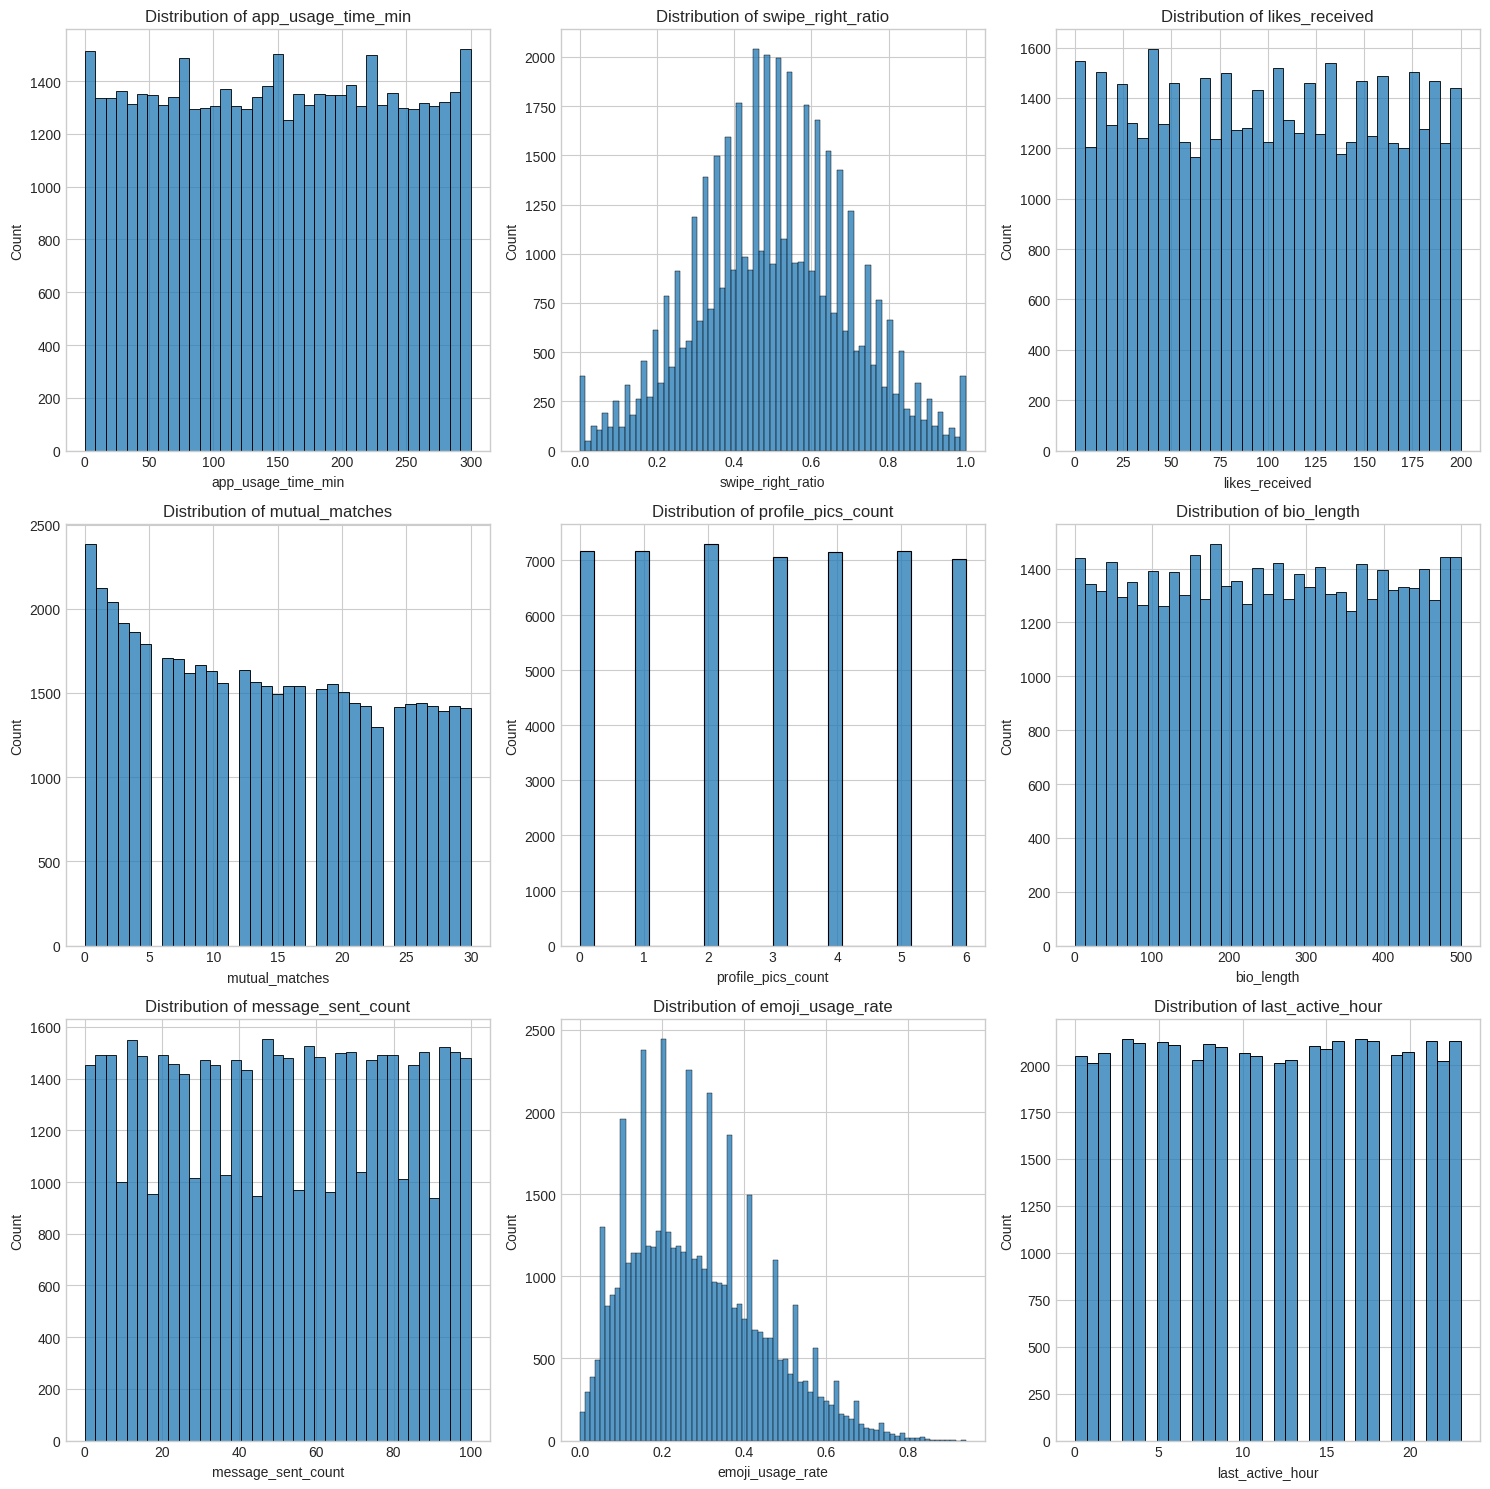

In [ ]:
cols = df.select_dtypes(include="number").columns

n_rows = (len(cols) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


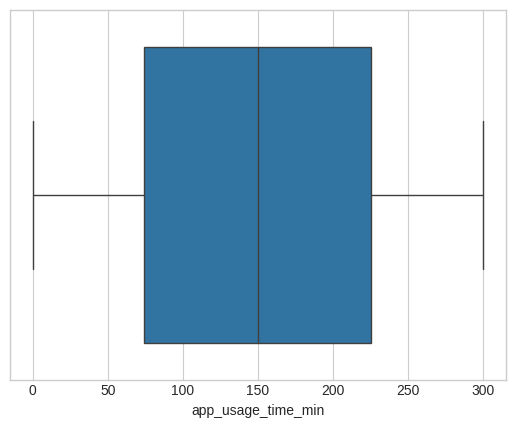

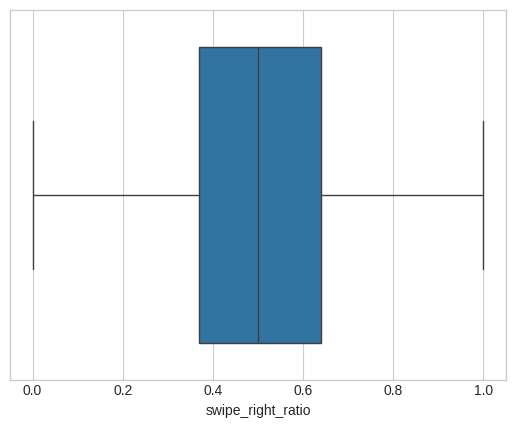

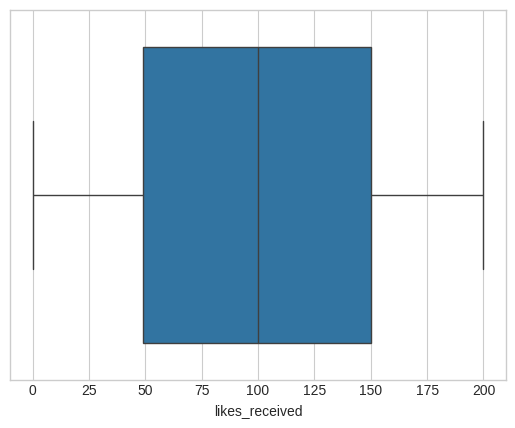

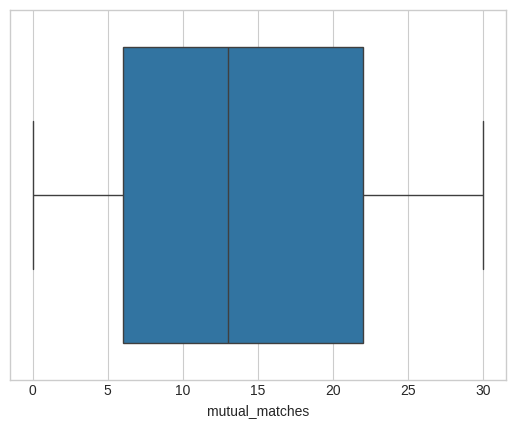

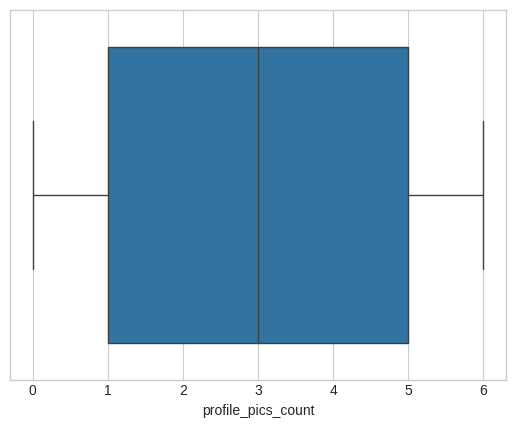

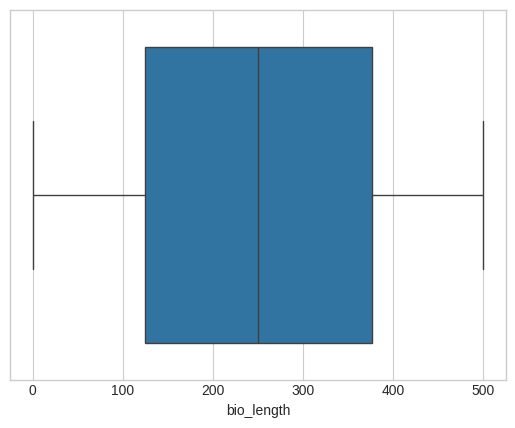

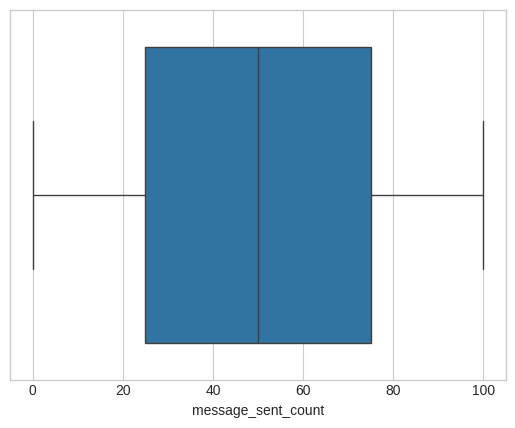

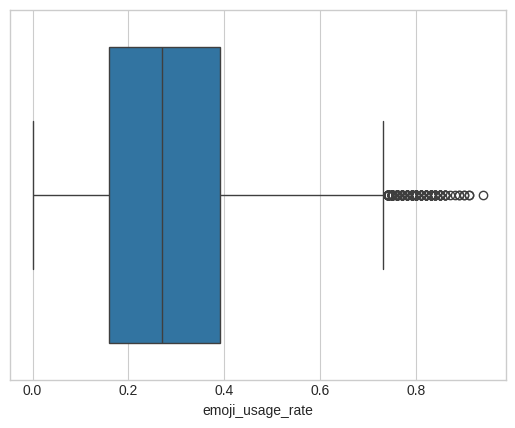

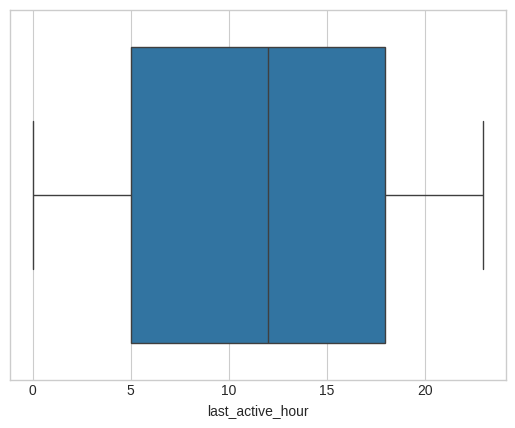

In [ ]:
# Boxplot to identify outliers
for i in df.select_dtypes(include="number").columns:
  sns.boxplot(data=df, x=i)
  plt.show()

<Axes: >

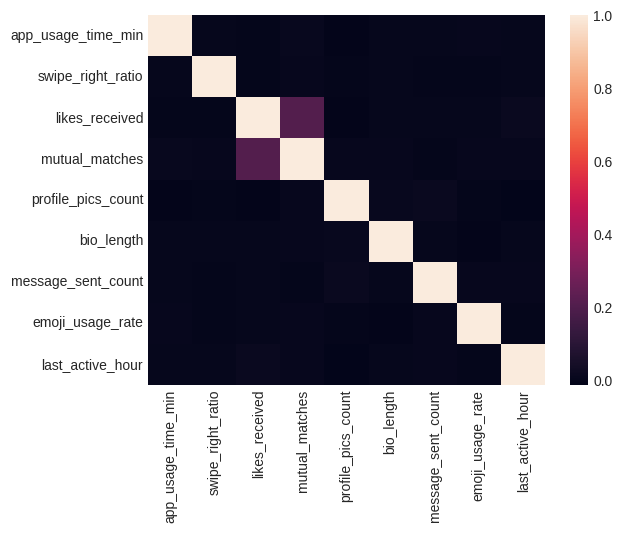

In [ ]:
# correlation
s = df.select_dtypes(include="number").corr()
sns.heatmap(s)

/tmp/ipykernel_5617/1749111416.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')
/tmp/ipykernel_5617/1749111416.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')
/tmp/ipykernel_5617/1749111416.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='viridis')
/tmp/ipykernel_5617/1749111416.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign

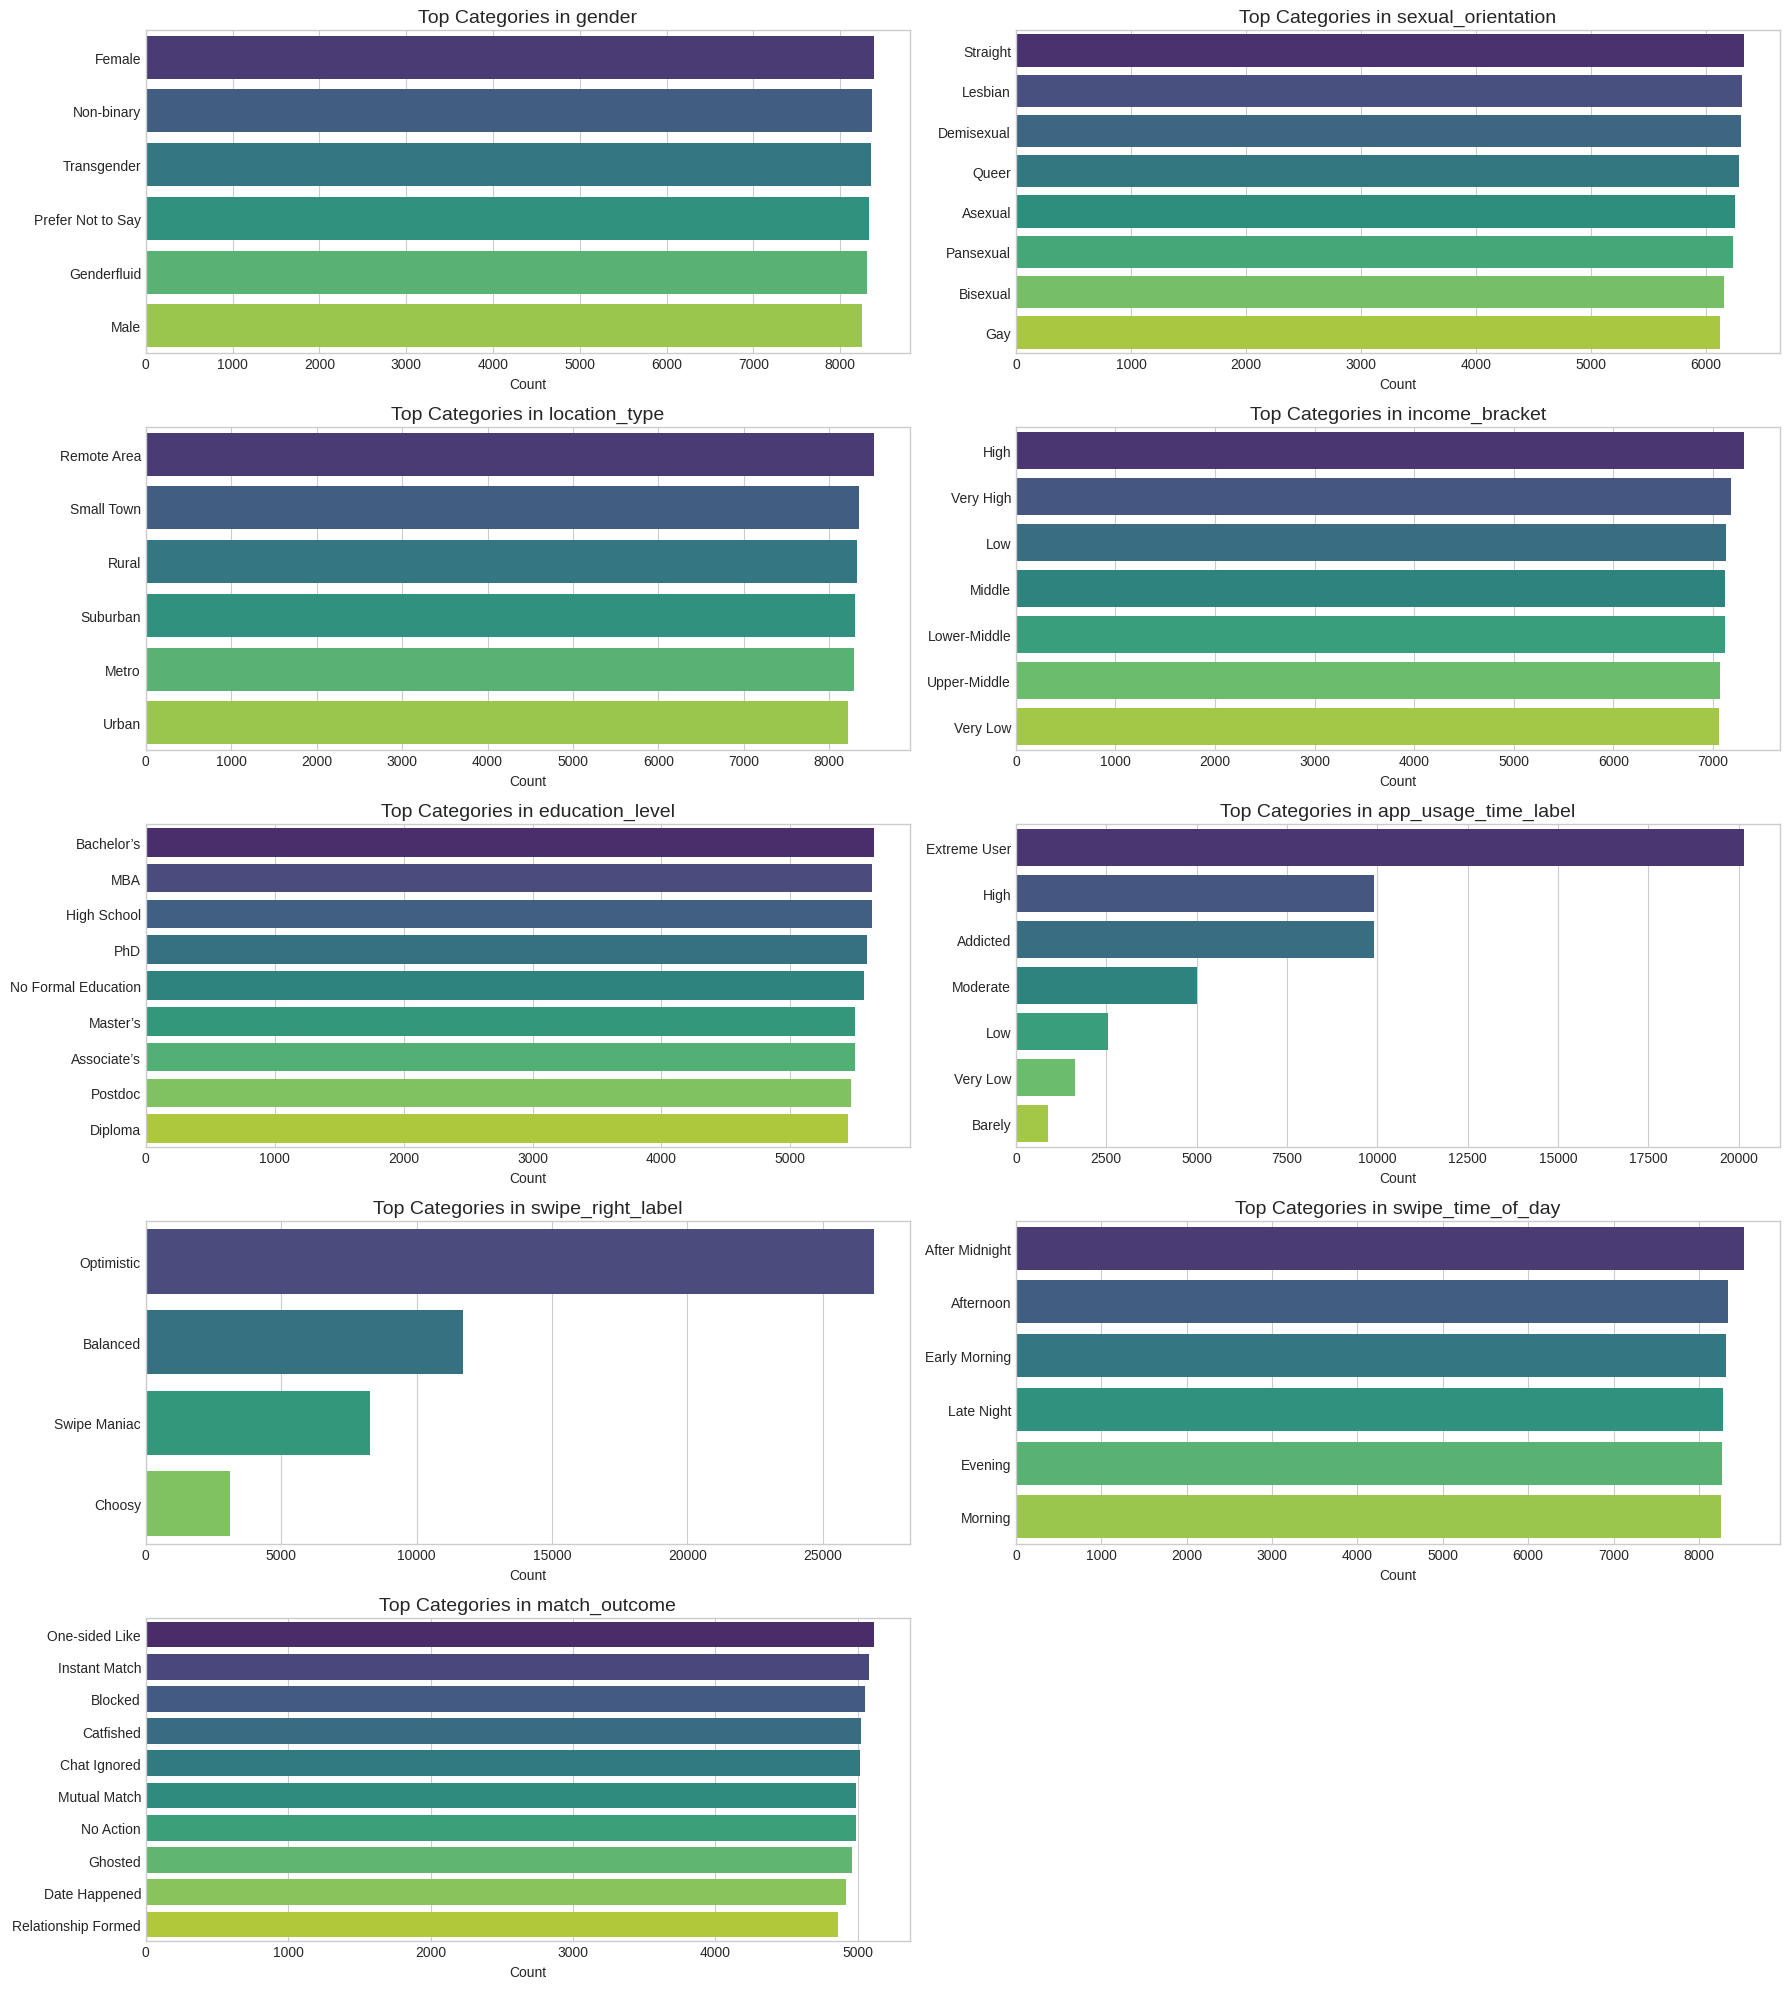

In [ ]:
cat_cols = [col for col in df.select_dtypes(include=['object']).columns if col != 'interest_tags']

plt.figure(figsize=(18, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(5, 2, i)
    order = df[col].value_counts().iloc[:10].index
    sns.countplot(data=df, y=col, order=order, palette='viridis')
    plt.title(f'Top Categories in {col}', fontsize=14)
    plt.xlabel('Count')
    plt.ylabel('')

plt.tight_layout()
plt.show()

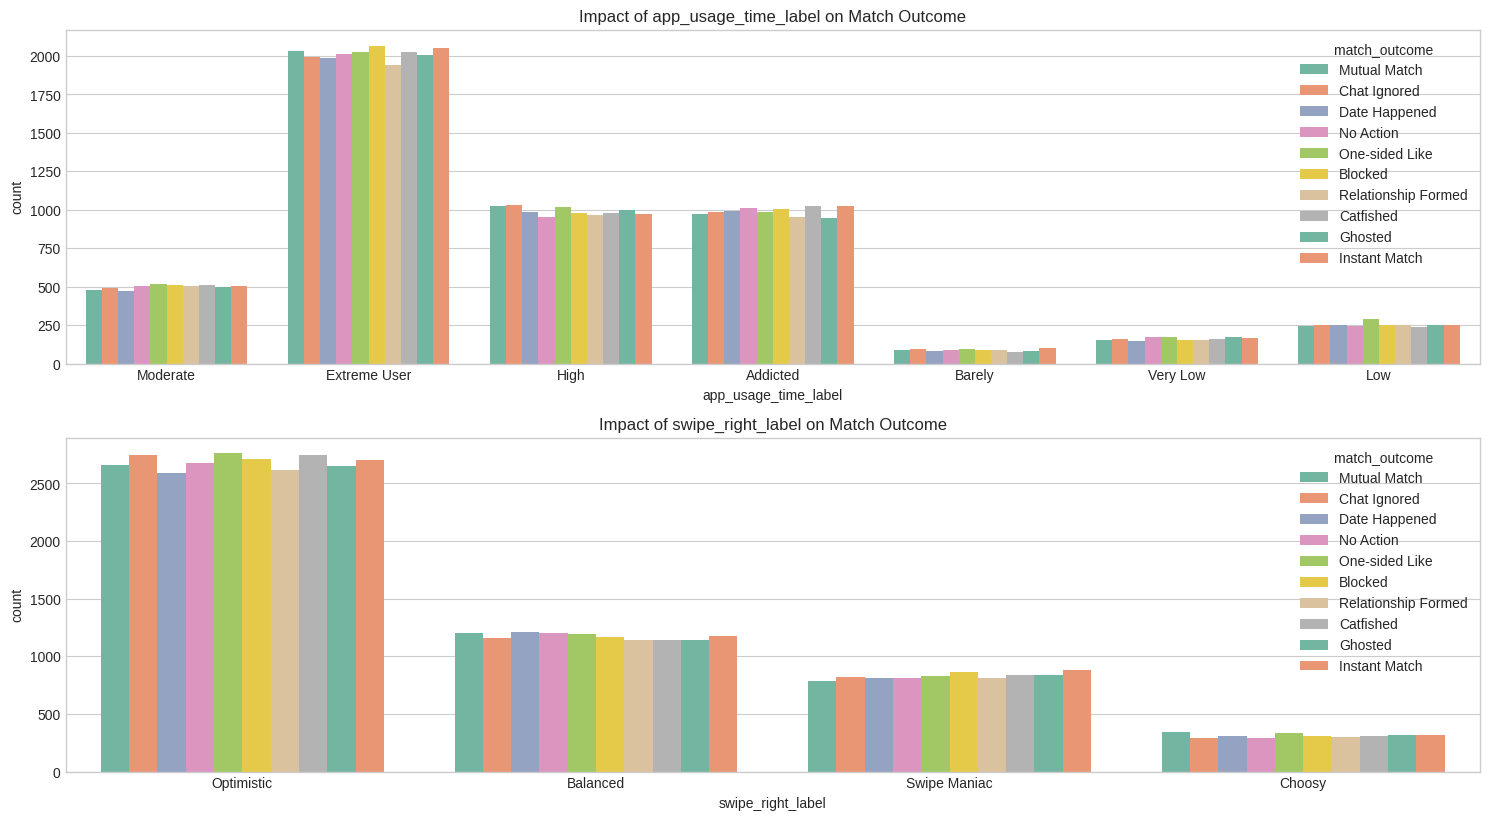

In [ ]:
# Compare Education and Income against Match Outcome
cols_to_compare = ['app_usage_time_label', 'swipe_right_label']

plt.figure(figsize=(15, 12))
for i, col in enumerate(cols_to_compare, 1):
    plt.subplot(3, 1, i)
    sns.countplot(data=df, x=col, hue='match_outcome', palette='Set2')
    plt.title(f'Impact of {col} on Match Outcome')
plt.tight_layout()
plt.show()

# 3.0 Data Cleaning

In [ ]:
# Redundancy columns
redundant_cols = ['app_usage_time_label', 'swipe_right_label']

df = df.drop(columns=redundant_cols)

print(f"Remaining columns: {df.columns.tolist()}")

Remaining columns: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'match_outcome']


In [ ]:
# finding missing values
df.isnull().sum()

,0
gender,0
sexual_orientation,0
location_type,0
income_bracket,0
education_level,0
interest_tags,0
app_usage_time_min,0
swipe_right_ratio,0
likes_received,0
mutual_matches,0


In [ ]:
# finding duplicates
int(df.duplicated().sum())

0

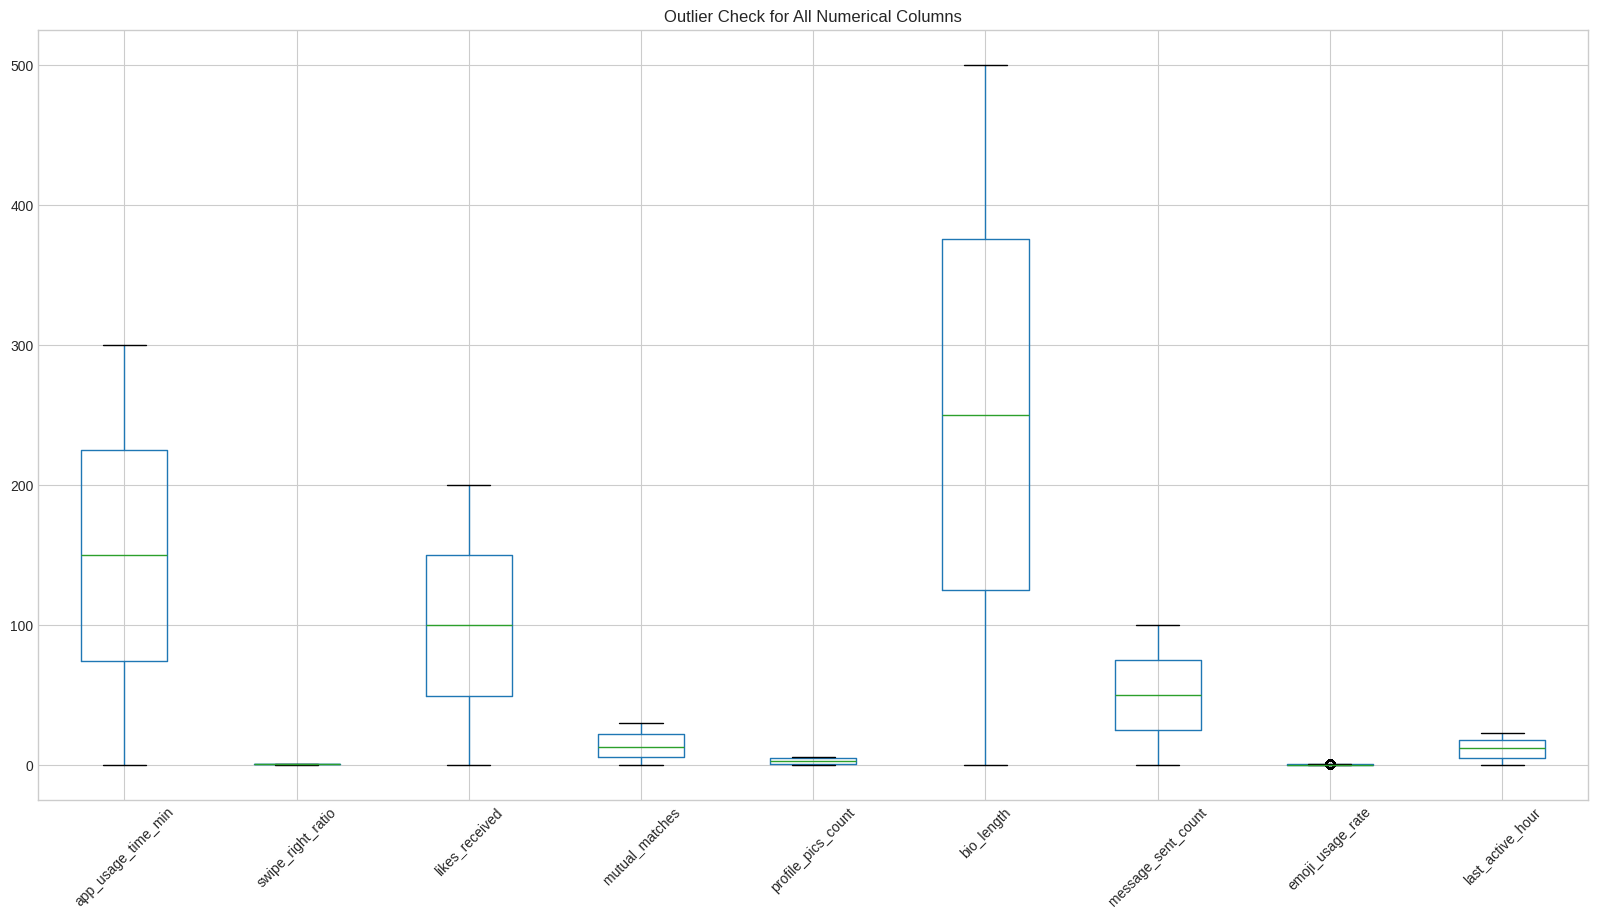

In [ ]:
# check outliers for all numerical data
all_num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 10))
df[all_num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Outlier Check for All Numerical Columns")
plt.show()

<Axes: >

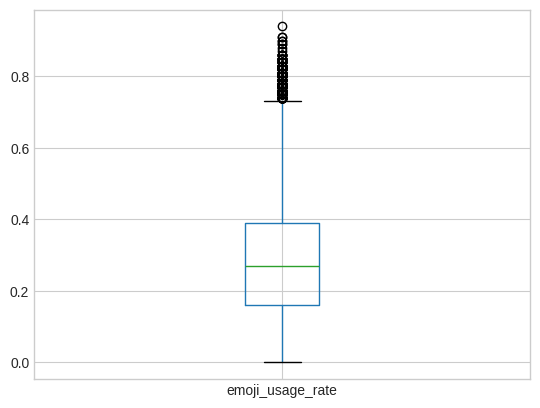

In [ ]:
df.boxplot(column=['emoji_usage_rate'])

In [ ]:
# IQR outlier check
def check_outliers(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Column: {col}")
        print(f"  - Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  - Outliers detected: {len(outliers)}")
        print("-" * 30)

check_outliers(df)

Column: app_usage_time_min
  - Lower Bound: -152.50, Upper Bound: 451.50
  - Outliers detected: 0
------------------------------
Column: swipe_right_ratio
  - Lower Bound: -0.04, Upper Bound: 1.04
  - Outliers detected: 0
------------------------------
Column: likes_received
  - Lower Bound: -102.50, Upper Bound: 301.50
  - Outliers detected: 0
------------------------------
Column: mutual_matches
  - Lower Bound: -18.00, Upper Bound: 46.00
  - Outliers detected: 0
------------------------------
Column: profile_pics_count
  - Lower Bound: -5.00, Upper Bound: 11.00
  - Outliers detected: 0
------------------------------
Column: bio_length
  - Lower Bound: -251.50, Upper Bound: 752.50
  - Outliers detected: 0
------------------------------
Column: message_sent_count
  - Lower Bound: -50.00, Upper Bound: 150.00
  - Outliers detected: 0
------------------------------
Column: emoji_usage_rate
  - Lower Bound: -0.19, Upper Bound: 0.74
  - Outliers detected: 311
------------------------------

In [ ]:
# Calculate the bounds for emoji_usage_rate
Q1 = df['emoji_usage_rate'].quantile(0.25)
Q3 = df['emoji_usage_rate'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

# Cap the outliers
df['emoji_usage_rate'] = df['emoji_usage_rate'].clip(upper=upper_limit)

print(f"Calculated Upper Bound: {upper_limit}")

Calculated Upper Bound: 0.7350000000000001


# 4.0 Normalization and Target Constructing

In [ ]:
behavioral_feats = ['message_sent_count', 'mutual_matches', 'likes_received',
                    'bio_length', 'profile_pics_count', 'emoji_usage_rate',
                    'swipe_right_ratio']
weights = np.array([0.25, 0.20, 0.20, 0.15, 0.10, 0.05, 0.05])

assert np.isclose(weights.sum(), 1.0), f"Weights must sum to 1.0, got {weights.sum()}"

# Min-Max Normalization
normalized = MinMaxScaler().fit_transform(df[behavioral_feats])
df['engagement_score'] = normalized @ weights
df['engagement_class'] = pd.qcut(df['engagement_score'], q=3,
                                  labels=['Low', 'Medium', 'High'])

print("\n✅ Target built successfully")
print(f"\nClass distribution:\n{df['engagement_class'].value_counts()}")
print(f"\nProportions:\n{df['engagement_class'].value_counts(normalize=True).round(3)}")
print(f"\nScore range: {df['engagement_score'].min():.2f} to {df['engagement_score'].max():.2f}")
df[['engagement_score', 'engagement_class']].head(10)


✅ Target built successfully

Class distribution:
engagement_class
Low       16667
High      16667
Medium    16666
Name: count, dtype: int64

Proportions:
engagement_class
Low       0.333
High      0.333
Medium    0.333
Name: proportion, dtype: float64

Score range: 0.06 to 0.92


,engagement_score,engagement_class
0,0.648190,High
1,0.438038,Medium
2,0.527924,Medium
3,0.314095,Low
4,0.395383,Low
5,0.670678,High
6,0.543702,Medium
7,0.398668,Low
8,0.513734,Medium
9,0.477001,Medium


In [ ]:
print("\nExamples of 'Low' engagement class:")
display(df[df['engagement_class'] == 'Low'].sample(5, random_state=42))

print("\nExamples of 'Medium' engagement class:")
display(df[df['engagement_class'] == 'Medium'].sample(5, random_state=42))

print("\nExamples of 'High' engagement class:")
display(df[df['engagement_class'] == 'High'].sample(5, random_state=42))


Examples of 'Low' engagement class:


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,engagement_score,engagement_class
40876,Female,Straight,Rural,Upper-Middle,High School,"Tattoos, Gaming, Parenting",219,0.35,22,22,1,201,7,0.25,6,After Midnight,Blocked,0.297640,Low
42668,Female,Asexual,Urban,Upper-Middle,Postdoc,"Skating, Clubbing, Investing",34,0.63,70,4,6,218,3,0.20,7,Afternoon,Relationship Formed,0.314672,Low
30257,Male,Pansexual,Remote Area,Very High,Postdoc,"Binge-Watching, Cars, Crafting",177,0.28,41,17,6,93,28,0.31,20,Late Night,Mutual Match,0.387322,Low
49475,Prefer Not to Say,Lesbian,Suburban,Low,No Formal Education,"Fashion, DIY, Pets",162,0.59,26,5,3,295,22,0.52,8,Evening,Instant Match,0.317707,Low
12440,Transgender,Demisexual,Rural,Lower-Middle,No Formal Education,"Photography, Gardening, Stand-up Comedy",174,0.38,120,16,5,33,10,0.13,5,Late Night,Date Happened,0.372744,Low



Examples of 'Medium' engagement class:


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,engagement_score,engagement_class
3763,Non-binary,Bisexual,Small Town,Middle,Master’s,"History, Writing, Astrology",121,0.56,102,21,2,321,21,0.15,5,After Midnight,Mutual Match,0.462337,Medium
17619,Non-binary,Asexual,Urban,High,High School,"Painting, Coding, Meditation",107,0.56,129,28,1,255,19,0.24,0,Early Morning,No Action,0.500660,Medium
5324,Transgender,Asexual,Metro,Middle,MBA,"Hiking, Tattoos, Crafting",206,0.46,27,20,5,77,45,0.44,3,Evening,No Action,0.432199,Medium
12155,Genderfluid,Bisexual,Remote Area,Lower-Middle,High School,"Gaming, Investing, Running",74,0.62,27,27,0,118,75,0.19,17,Afternoon,One-sided Like,0.473825,Medium
16547,Female,Bisexual,Rural,Very High,Diploma,"Skating, Poetry, Movies",14,0.53,148,27,2,240,6,0.20,4,Afternoon,Chat Ignored,0.488439,Medium



Examples of 'High' engagement class:


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,engagement_score,engagement_class
40783,Prefer Not to Say,Straight,Urban,Upper-Middle,Diploma,"Art, Stand-up Comedy, Fitness",230,0.76,173,2,3,159,92,0.15,17,Morning,No Action,0.562237,High
42537,Transgender,Demisexual,Suburban,Lower-Middle,MBA,"Parenting, Makeup, Poetry",2,0.60,188,7,2,138,67,0.61,9,Afternoon,Ghosted,0.548397,High
30438,Female,Gay,Urban,Middle,PhD,"K-pop, History, Board Games",258,0.67,167,18,0,385,77,0.43,16,Early Morning,One-sided Like,0.657752,High
49495,Genderfluid,Gay,Urban,Lower-Middle,No Formal Education,"Movies, Crafting, Politics",124,0.92,60,20,5,450,35,0.19,2,Afternoon,Relationship Formed,0.558092,High
12168,Transgender,Queer,Metro,Very High,MBA,"Investing, Politics, Gaming",299,0.41,159,23,1,422,41,0.37,15,Late Night,Catfished,0.603770,High


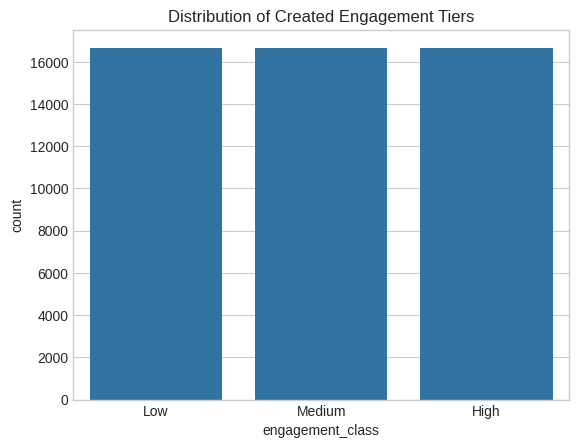

In [ ]:
sns.countplot(data=df, x='engagement_class')
plt.title("Distribution of Created Engagement Tiers")
plt.show()

# 5.0 Feature Selection
Separate X and Y, drop leakage columns

In [ ]:
# Drop match_outcome (already proved it's noise)
# Drop engagement_score (redundant with engagement_class)
leakage_cols = [
    'match_outcome',
    'engagement_score',
    'engagement_class',
]

X = df.drop(columns=leakage_cols)
y = df['engagement_class']

print(f"✅ Features (X): {X.shape[1]} columns, {len(X)} rows")
print(f"✅ Target (y): {len(y)} labels")
print(f"\nRemaining feature columns:\n{list(X.columns)}")
print(f"\nFeature data types:\n{X.dtypes}")

✅ Features (X): 16 columns, 50000 rows
✅ Target (y): 50000 labels

Remaining feature columns:
['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day']

Feature data types:
gender                 object
sexual_orientation     object
location_type          object
income_bracket         object
education_level        object
interest_tags          object
app_usage_time_min      int64
swipe_right_ratio     float64
likes_received          int64
mutual_matches          int64
profile_pics_count      int64
bio_length              int64
message_sent_count      int64
emoji_usage_rate      float64
last_active_hour        int64
swipe_time_of_day      object
dtype: object


# 6.0 Encoding
interest_tags Multi-Hot Encoding

In [ ]:
# Multi-hot encode interest_tags (split by comma)
interest_dummies = X['interest_tags'].str.get_dummies(sep=', ')

# Prefix with 'interest_' for clarity
interest_dummies = interest_dummies.add_prefix('interest_')

# Add to X, drop original column
X = pd.concat([X.drop(columns=['interest_tags']), interest_dummies], axis=1)

print(f"✅ Interest tags expanded into {interest_dummies.shape[1]} columns")
print(f"New X shape: {X.shape}")
print(f"\nInterest columns:\n{list(interest_dummies.columns)}")

✅ Interest tags expanded into 49 columns
New X shape: (50000, 64)

Interest columns:
['interest_Anime', 'interest_Art', 'interest_Astrology', 'interest_Binge-Watching', 'interest_Board Games', 'interest_Cars', 'interest_Clubbing', 'interest_Coding', 'interest_Cooking', 'interest_Crafting', 'interest_DIY', 'interest_Dancing', 'interest_Fashion', 'interest_Fitness', 'interest_Foodie', 'interest_Gaming', 'interest_Gardening', 'interest_Hiking', 'interest_History', 'interest_Investing', 'interest_K-pop', 'interest_Languages', 'interest_MMA', 'interest_Makeup', 'interest_Meditation', 'interest_Memes', 'interest_Motorcycling', 'interest_Movies', 'interest_Music', 'interest_Painting', 'interest_Parenting', 'interest_Pets', 'interest_Photography', 'interest_Podcasts', 'interest_Poetry', 'interest_Politics', 'interest_Reading', 'interest_Running', 'interest_Skating', 'interest_Sneaker Culture', 'interest_Social Activism', 'interest_Spirituality', 'interest_Stand-up Comedy', 'interest_Startups',

Categorical Encoding (Ordinal and One-Hot Encoding)

In [ ]:
print("Unique values in each categorical column:\n")
for col in ['gender', 'sexual_orientation', 'location_type', 'income_bracket',
            'education_level', 'swipe_time_of_day']:
    print(f"{col}:")
    print(f"  {sorted(X[col].unique().tolist())}\n")

Unique values in each categorical column:

gender:
  ['Female', 'Genderfluid', 'Male', 'Non-binary', 'Prefer Not to Say', 'Transgender']

sexual_orientation:
  ['Asexual', 'Bisexual', 'Demisexual', 'Gay', 'Lesbian', 'Pansexual', 'Queer', 'Straight']

location_type:
  ['Metro', 'Remote Area', 'Rural', 'Small Town', 'Suburban', 'Urban']

income_bracket:
  ['High', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'Very High', 'Very Low']

education_level:
  ['Associate’s', 'Bachelor’s', 'Diploma', 'High School', 'MBA', 'Master’s', 'No Formal Education', 'PhD', 'Postdoc']

swipe_time_of_day:
  ['After Midnight', 'Afternoon', 'Early Morning', 'Evening', 'Late Night', 'Morning']



In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Ordinal columns (natural order from low to high)
income_order_full = ['Very Low', 'Low', 'Lower-Middle', 'Middle',
                     'Upper-Middle', 'High', 'Very High']

education_order_full = ['No Formal Education', 'High School', 'Diploma',
                        'Associate’s', 'Bachelor’s', 'MBA', 'Master’s',
                        'PhD', 'Postdoc']

income_order = [x for x in income_order_full if x in X['income_bracket'].unique()]
education_order = [x for x in education_order_full if x in X['education_level'].unique()]

print(f"Income order used: {income_order}")
print(f"Education order used: {education_order}\n")

# Check if anything in data is NOT in our order list (would cause errors)
missing_income = set(X['income_bracket'].unique()) - set(income_order)
missing_edu = set(X['education_level'].unique()) - set(education_order)
if missing_income:
    print(f"⚠️ Income values not in our order list: {missing_income}")
if missing_edu:
    print(f"⚠️ Education values not in our order list: {missing_edu}")

# Encode
ord_enc = OrdinalEncoder(categories=[income_order, education_order])
X[['income_bracket', 'education_level']] = ord_enc.fit_transform(
    X[['income_bracket', 'education_level']])

# One-hot columns (no natural order)
one_hot_cols = ['gender', 'sexual_orientation', 'location_type', 'swipe_time_of_day']
X = pd.get_dummies(X, columns=one_hot_cols, drop_first=True, dtype=int)

print(f"\n✅ Categorical encoding done")
print(f"X shape: {X.shape}")
print(f"\nData types:\n{X.dtypes.value_counts()}")

Income order used: ['Very Low', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High', 'Very High']
Education order used: ['No Formal Education', 'High School', 'Diploma', 'Associate’s', 'Bachelor’s', 'MBA', 'Master’s', 'PhD', 'Postdoc']


✅ Categorical encoding done
X shape: (50000, 82)

Data types:
int64      78
float64     4
Name: count, dtype: int64


In [ ]:
print("First 5 rows of ordinal encoded and scaled 'income_bracket' and 'education_level' in X:")
display(X[['income_bracket', 'education_level']].head())

First 5 rows of ordinal encoded and scaled 'income_bracket' and 'education_level' in X:


,income_bracket,education_level
0,5.0,4.0
1,4.0,0.0
2,1.0,6.0
3,0.0,8.0
4,3.0,4.0


In [ ]:
# Define the logical order
engagement_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
class_names = [reverse_mapping[i] for i in range(3)]

# Apply the mapping to create our numerical target (y)
y = df['engagement_class'].map(engagement_mapping)

# Creates ['Low', 'Medium', 'High']
class_names = [k for k, v in sorted(engagement_mapping.items(), key=lambda item: item[1])]

print(f"✅ Target 'engagement_class' manually encoded.")
print(f"🔗 Mapping: {engagement_mapping}")
print(f"📊 Visualization Order: {class_names}")

# Verify the balance
print("\nClass Distribution in y:")
distribution = y.value_counts().sort_index().reset_index()
distribution.columns = ['Label', 'Count']
distribution['Engagement Class'] = distribution['Label'].map(reverse_mapping)
distribution = distribution[['Label', 'Engagement Class', 'Count']]
print(distribution.to_string(index=False))

✅ Target 'engagement_class' manually encoded.
🔗 Mapping: {'Low': 0, 'Medium': 1, 'High': 2}
📊 Visualization Order: ['Low', 'Medium', 'High']

Class Distribution in y:
Label Engagement Class  Count
    0              Low  16667
    1           Medium  16666
    2             High  16667


# 7.0 Final Scaling

In [ ]:
numeric_cols = ['app_usage_time_min', 'last_active_hour', 'income_bracket', 'education_level'] + behavioral_feats

# Scale for all numerical features except hot-encoded features
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(f"✅ Scaling done")
print(f"\nFinal X shape: {X.shape}")
pd.set_option('display.max_columns', None)
X.head()

✅ Scaling done

Final X shape: (50000, 82)


,income_bracket,education_level,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,interest_Anime,interest_Art,interest_Astrology,interest_Binge-Watching,interest_Board Games,interest_Cars,interest_Clubbing,interest_Coding,interest_Cooking,interest_Crafting,interest_DIY,interest_Dancing,interest_Fashion,interest_Fitness,interest_Foodie,interest_Gaming,interest_Gardening,interest_Hiking,interest_History,interest_Investing,interest_K-pop,interest_Languages,interest_MMA,interest_Makeup,interest_Meditation,interest_Memes,interest_Motorcycling,interest_Movies,interest_Music,interest_Painting,interest_Parenting,interest_Pets,interest_Photography,interest_Podcasts,interest_Poetry,interest_Politics,interest_Reading,interest_Running,interest_Skating,interest_Sneaker Culture,interest_Social Activism,interest_Spirituality,interest_Stand-up Comedy,interest_Startups,interest_Tattoos,interest_Tech,interest_Traveling,interest_Writing,interest_Yoga,gender_Genderfluid,gender_Male,gender_Non-binary,gender_Prefer Not to Say,gender_Transgender,sexual_orientation_Bisexual,sexual_orientation_Demisexual,sexual_orientation_Gay,sexual_orientation_Lesbian,sexual_orientation_Pansexual,sexual_orientation_Queer,sexual_orientation_Straight,location_type_Remote Area,location_type_Rural,location_type_Small Town,location_type_Suburban,location_type_Urban,swipe_time_of_day_Afternoon,swipe_time_of_day_Early Morning,swipe_time_of_day_Evening,swipe_time_of_day_Late Night,swipe_time_of_day_Morning
0,0.993121,0.001923,-1.125564,0.503097,1.266875,1.002657,0.506961,-1.423861,0.854646,0.465283,0.213600,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0
1,0.493246,-1.548882,1.483942,0.300530,0.128870,-0.754518,0.006150,0.351007,-0.516734,0.842179,-1.664903,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,-1.006378,0.777326,-1.160051,-0.459093,-0.147010,1.441951,-0.494661,0.406255,-0.585303,0.779363,-1.520402,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
3,-1.506253,1.552728,0.403354,-0.914868,0.818570,-0.864341,1.007773,-1.486016,-1.545268,-1.356379,1.369602,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,-0.006628,0.001923,-0.769200,-0.914868,-0.095283,-0.315224,-0.995473,0.641063,-0.551018,-1.105115,1.514102,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


/tmp/ipykernel_5617/2313826694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df, x='engagement_class', y=feat,
/tmp/ipykernel_5617/2313826694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df, x='engagement_class', y=feat,
/tmp/ipykernel_5617/2313826694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df, x='engagement_class', y=feat,


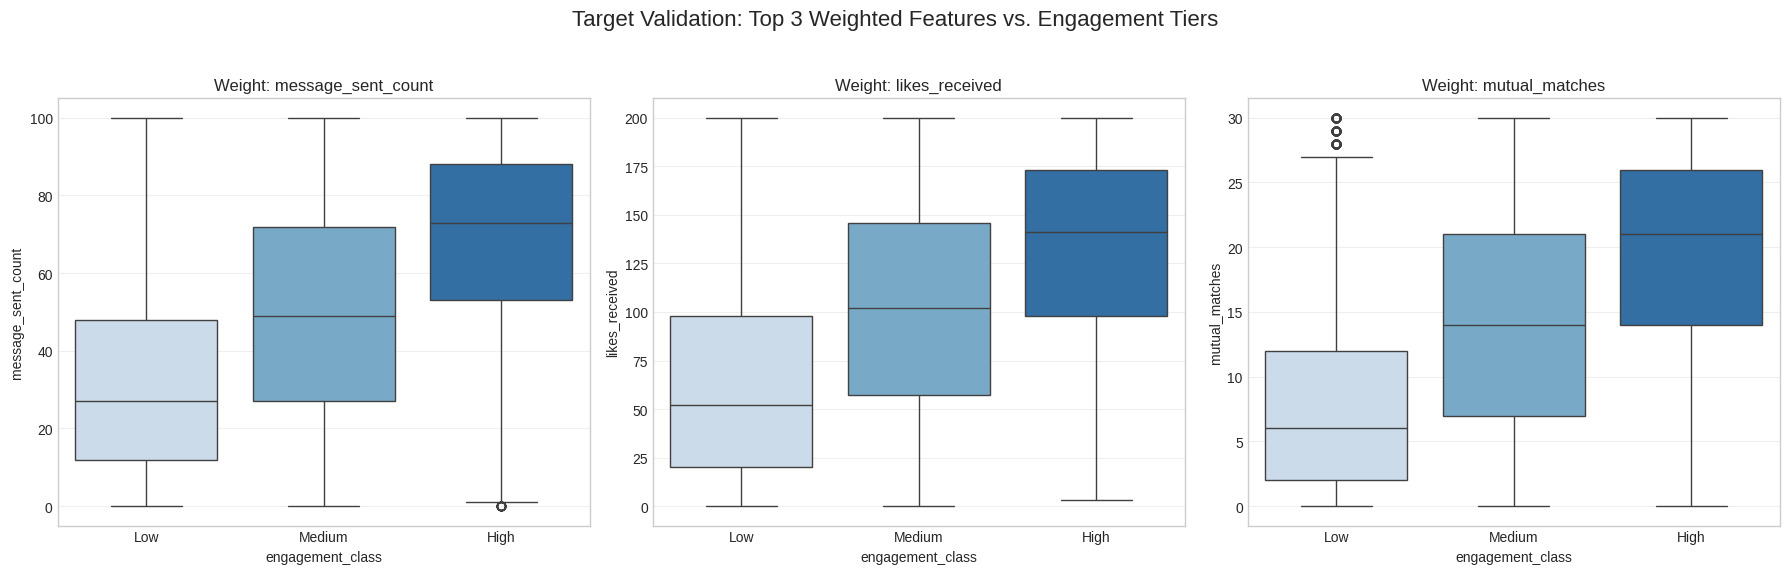

In [ ]:
# Validates that the high tier users are actually also highly performed in the top 3 weighted features in our target construction formula
top_drivers = ['message_sent_count', 'likes_received', 'mutual_matches']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feat in enumerate(top_drivers):
    sns.boxplot(ax=axes[i], data=df, x='engagement_class', y=feat,
                order=['Low', 'Medium', 'High'], palette='Blues')
    axes[i].set_title(f'Weight: {feat}')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle("Target Validation: Top 3 Weighted Features vs. Engagement Tiers", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8.0 Train/test split (40k/10k stratified)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=10000,       # exactly 10k for test
    random_state=42,       # reproducibility
    stratify=y             # keeps class balance in both splits
)

print(f"✅ Split done")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3).sort_index().rename(index=reverse_mapping)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3).sort_index().rename(index=reverse_mapping)}")

✅ Split done
X_train: (40000, 82)
X_test:  (10000, 82)

Train class balance:
engagement_class
Low       0.333
Medium    0.333
High      0.333
Name: proportion, dtype: float64

Test class balance:
engagement_class
Low       0.333
Medium    0.333
High      0.333
Name: proportion, dtype: float64


In [ ]:
print("\nFinal features after preprocessing:")
print(X.columns.tolist())
print("\nShape of X_train (ready for model training):")
print(X_train.shape)
print("\nFirst 5 rows of the processed features (X_train):")
display(X_train.head())


Final features after preprocessing:
['income_bracket', 'education_level', 'app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'interest_Anime', 'interest_Art', 'interest_Astrology', 'interest_Binge-Watching', 'interest_Board Games', 'interest_Cars', 'interest_Clubbing', 'interest_Coding', 'interest_Cooking', 'interest_Crafting', 'interest_DIY', 'interest_Dancing', 'interest_Fashion', 'interest_Fitness', 'interest_Foodie', 'interest_Gaming', 'interest_Gardening', 'interest_Hiking', 'interest_History', 'interest_Investing', 'interest_K-pop', 'interest_Languages', 'interest_MMA', 'interest_Makeup', 'interest_Meditation', 'interest_Memes', 'interest_Motorcycling', 'interest_Movies', 'interest_Music', 'interest_Painting', 'interest_Parenting', 'interest_Pets', 'interest_Photography', 'interest_Podcasts', 'interest_Poetry', 'interest_Politics', 'interest_Reading', 'in

,income_bracket,education_level,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,interest_Anime,interest_Art,interest_Astrology,interest_Binge-Watching,interest_Board Games,interest_Cars,interest_Clubbing,interest_Coding,interest_Cooking,interest_Crafting,interest_DIY,interest_Dancing,interest_Fashion,interest_Fitness,interest_Foodie,interest_Gaming,interest_Gardening,interest_Hiking,interest_History,interest_Investing,interest_K-pop,interest_Languages,interest_MMA,interest_Makeup,interest_Meditation,interest_Memes,interest_Motorcycling,interest_Movies,interest_Music,interest_Painting,interest_Parenting,interest_Pets,interest_Photography,interest_Podcasts,interest_Poetry,interest_Politics,interest_Reading,interest_Running,interest_Skating,interest_Sneaker Culture,interest_Social Activism,interest_Spirituality,interest_Stand-up Comedy,interest_Startups,interest_Tattoos,interest_Tech,interest_Traveling,interest_Writing,interest_Yoga,gender_Genderfluid,gender_Male,gender_Non-binary,gender_Prefer Not to Say,gender_Transgender,sexual_orientation_Bisexual,sexual_orientation_Demisexual,sexual_orientation_Gay,sexual_orientation_Lesbian,sexual_orientation_Pansexual,sexual_orientation_Queer,sexual_orientation_Straight,location_type_Remote Area,location_type_Rural,location_type_Small Town,location_type_Suburban,location_type_Urban,swipe_time_of_day_Afternoon,swipe_time_of_day_Early Morning,swipe_time_of_day_Evening,swipe_time_of_day_Late Night,swipe_time_of_day_Morning
18788,0.493246,0.389624,-0.309375,-0.509735,0.766842,0.453540,1.007773,-0.201481,-1.716691,-0.791035,0.502601,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
8171,-1.506253,-0.385778,0.495319,0.604380,0.439235,-1.083988,1.508584,-0.090984,0.237525,-0.916667,-1.664903,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
17767,0.493246,0.001923,0.460832,-0.408452,-1.629866,-1.193812,-0.995473,-1.479110,-0.962432,-0.225692,-1.664903,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0
19750,-1.006378,-1.161181,-1.401459,0.857588,0.525447,-1.523282,0.506961,0.212885,1.300344,0.151204,-1.086902,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0
5933,-1.506253,0.777326,-1.527910,0.249889,-0.129768,0.892834,0.006150,0.364819,-0.482449,-1.230747,0.791601,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0


# 9.0 Model Training and Hyperparameter Tuning

Restore saved model training data

In [ ]:
import joblib
import os

checkpoint_path = '/content/drive/MyDrive/ML OCC11 G13/model_checkpoint.pkl'

if os.path.exists(checkpoint_path):
    print("📂 Found saved models! Restoring session...")
    checkpoint = joblib.load(checkpoint_path)

    # Restore all checkpoint data instantly
    best_estimators = checkpoint['best_estimators']
    baseline_results = checkpoint['baseline_results']
    tuned_results = checkpoint['tuned_results']
    all_predictions = checkpoint['all_predictions']
    baseline_models = checkpoint['baseline_models']

    print("🚀 Done! All models loaded. Can now run evaluation charts now.")
else:
    print("⚠️ No checkpoint found.")

📂 Found saved models! Restoring session...
🚀 Done! All models loaded. Can now run evaluation charts now.


Model Training and Hyperparameter Tuning Core Code

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Check if checkpoint exists, if no then will repeat the training and tuning process
if os.path.exists(checkpoint_path):
  print("⏭️ Skipping model training and tuning because saved models are loaded.")
else:
  # ---------- Model Training ----------------
  baseline_models = {
      'Logistic Regression': LogisticRegression(max_iter=1000),
      'Random Forest': RandomForestClassifier(random_state=42),
      'XGBoost': XGBClassifier(random_state=42),
      'SVM': SVC(probability=True, random_state=42),
      'KNN': KNeighborsClassifier(),
      'Neural Network': MLPClassifier(max_iter=500, random_state=42)
  }

  baseline_results = {}
  all_predictions = {}

  for i, (name, model) in enumerate(baseline_models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    baseline_results[name] = acc
    all_predictions[name] = y_pred

# ---------- Hyperparameter tuning ----------------

  # Define Search Spaces (Grids)
  param_grids = {
      'Logistic Regression': {'C': [0.1, 1, 10]},
      'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
      'XGBoost': {'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200]},
      'SVM': {'C': [0.1, 1], 'kernel': ['linear', 'rbf']},
      'KNN': {'n_neighbors': [3, 5, 7]},
      'Neural Network': {'hidden_layer_sizes': [(100,), (100, 50)], 'alpha': [0.0001, 0.05]}
  }

  tuned_results = {}
  best_estimators = {}

  # Perform Tuning
  for name, model in baseline_models.items():
      print(f"⚙️ Tuning {name}...")

      if name in ['Logistic Regression', 'KNN']:
          search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=5, n_jobs=-1)
      else:
          search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name],
                                      n_iter=5, cv=3, n_jobs=-1, random_state=42)

      search.fit(X_train, y_train)
      best_model = search.best_estimator_
      y_pred_tuned = best_model.predict(X_test)

      best_estimators[name] = best_model
      tuned_results[name] = {
          'accuracy': accuracy_score(y_test, y_pred_tuned),
          'params': search.best_params_,
          'y_pred': y_pred_tuned,
          'method': 'GridSearchCV' if name in ['Logistic Regression', 'KNN'] else 'RandomizedSearchCV'
      }
      print(f"✅ {name} optimized.")

  checkpoint = {
      'baseline_results': baseline_results,
      'all_predictions': all_predictions,
      'baseline_models': baseline_models,
      'tuned_results': tuned_results,
      'best_estimators': best_estimators
  }

  joblib.dump(checkpoint, checkpoint_path)
  print("💾 ALL models (Baseline & Tuned) saved to Drive successfully!")

⏭️ Skipping model training and tuning because saved models are loaded.


Visual Evaluation: Baseline Confusion Matrices and Comparison Reports (Untuned)

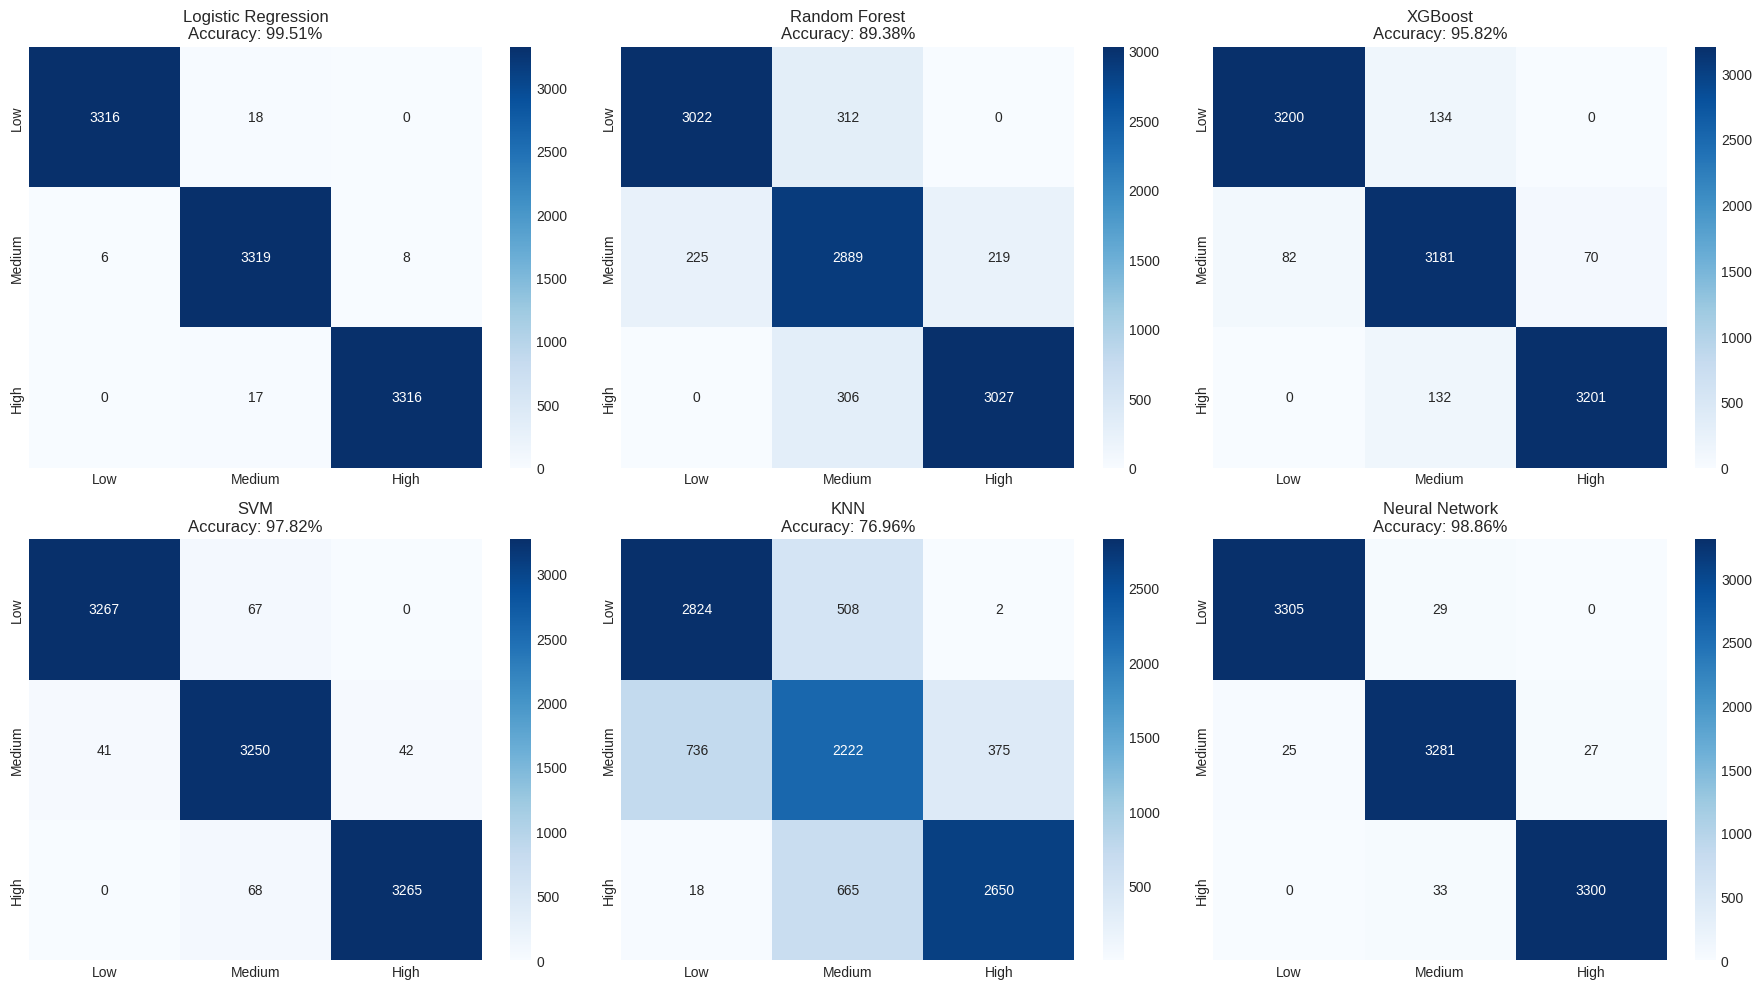


📜 Performance Statistics

🔹 MODEL: Logistic Regression
Final Accuracy: 99.51%
              precision    recall  f1-score   support

         Low       1.00      0.99      1.00      3334
      Medium       0.99      1.00      0.99      3333
        High       1.00      0.99      1.00      3333

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

-------------------------------------------------------
🔹 MODEL: Random Forest
Final Accuracy: 89.38%
              precision    recall  f1-score   support

         Low       0.93      0.91      0.92      3334
      Medium       0.82      0.87      0.84      3333
        High       0.93      0.91      0.92      3333

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000

-------------------------------------------------------
🔹

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(baseline_results.keys()):
    y_pred = all_predictions[name]
    acc = baseline_results[name]

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f"{name}\nAccuracy: {acc:.2%}")

plt.tight_layout()
plt.show()

print("\n" + "="*30)
print("📜 Performance Statistics")
print("="*30 + "\n")

for name in baseline_models.keys():
    y_pred = all_predictions[name]
    acc = baseline_results[name]

    print(f"🔹 MODEL: {name}")
    print(f"Final Accuracy: {acc:.2%}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    print("-" * 55)

Visual Evaluation: Tuned Confusion Matrices and Comparison Reports

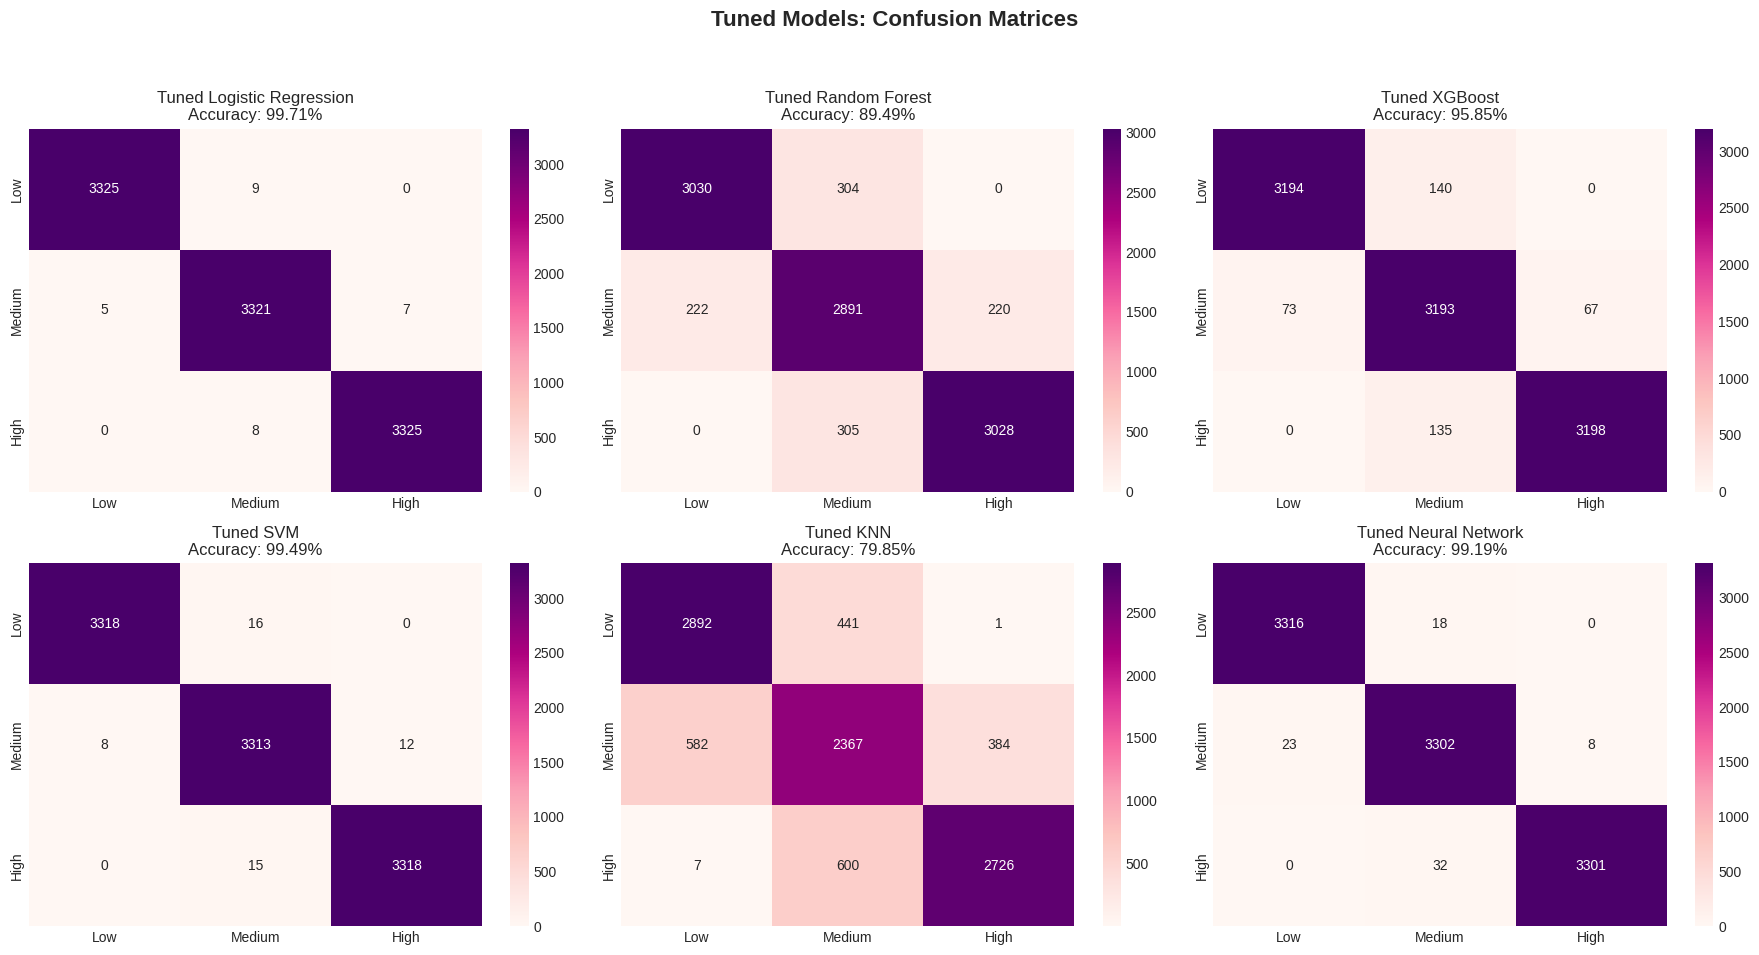


                    MODEL COMPARISON: BEFORE VS AFTER TUNING                    

📊 ALGORITHM: Logistic Regression
🛠️  Method Used: GridSearchCV
🏆 Best Parameters: {'C': 10}
📈 Baseline Acc: 99.51% | Tuned Acc: 99.71%

[Detailed Tuned Report for Logistic Regression]
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3334
      Medium       0.99      1.00      1.00      3333
        High       1.00      1.00      1.00      3333

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

--------------------------------------------------------------------------------
📊 ALGORITHM: Random Forest
🛠️  Method Used: RandomizedSearchCV
🏆 Best Parameters: {'n_estimators': 200, 'max_depth': 20}
📈 Baseline Acc: 89.38% | Tuned Acc: 89.49%

[Detailed Tuned Report for Random Forest]
              precision    recall  f1-score   support

         

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(baseline_models.keys()):
  y_pred_tuned = tuned_results[name]['y_pred']
  acc_tuned = tuned_results[name]['accuracy']

  cm = confusion_matrix(y_test, tuned_results[name]['y_pred'])
  sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=axes[i],
              xticklabels=class_names, yticklabels=class_names)
  axes[i].set_title(f"Tuned {name}\nAccuracy: {tuned_results[name]['accuracy']:.2%}")

plt.suptitle("Tuned Models: Confusion Matrices", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Comparison Reports
print("\n" + "="*80)
print(f"{'MODEL COMPARISON: BEFORE VS AFTER TUNING':^80}")
print("="*80 + "\n")

for name in baseline_models.keys():
    print(f"📊 ALGORITHM: {name}")
    print(f"🛠️  Method Used: {tuned_results[name]['method']}")
    print(f"🏆 Best Parameters: {tuned_results[name]['params']}")
    print(f"📈 Baseline Acc: {baseline_results[name]:.2%} | Tuned Acc: {tuned_results[name]['accuracy']:.2%}")

    print(f"\n[Detailed Tuned Report for {name}]")
    print(classification_report(y_test, tuned_results[name]['y_pred'], target_names=class_names))
    print("-" * 80)

 # 10.0 Auto-sklearn (Automated Machine Learning)

Google Colab notebook has dependencies conflict with auto-sklearn, so we run it in our local computer using Docker image. Below is the result of auto-sklearn

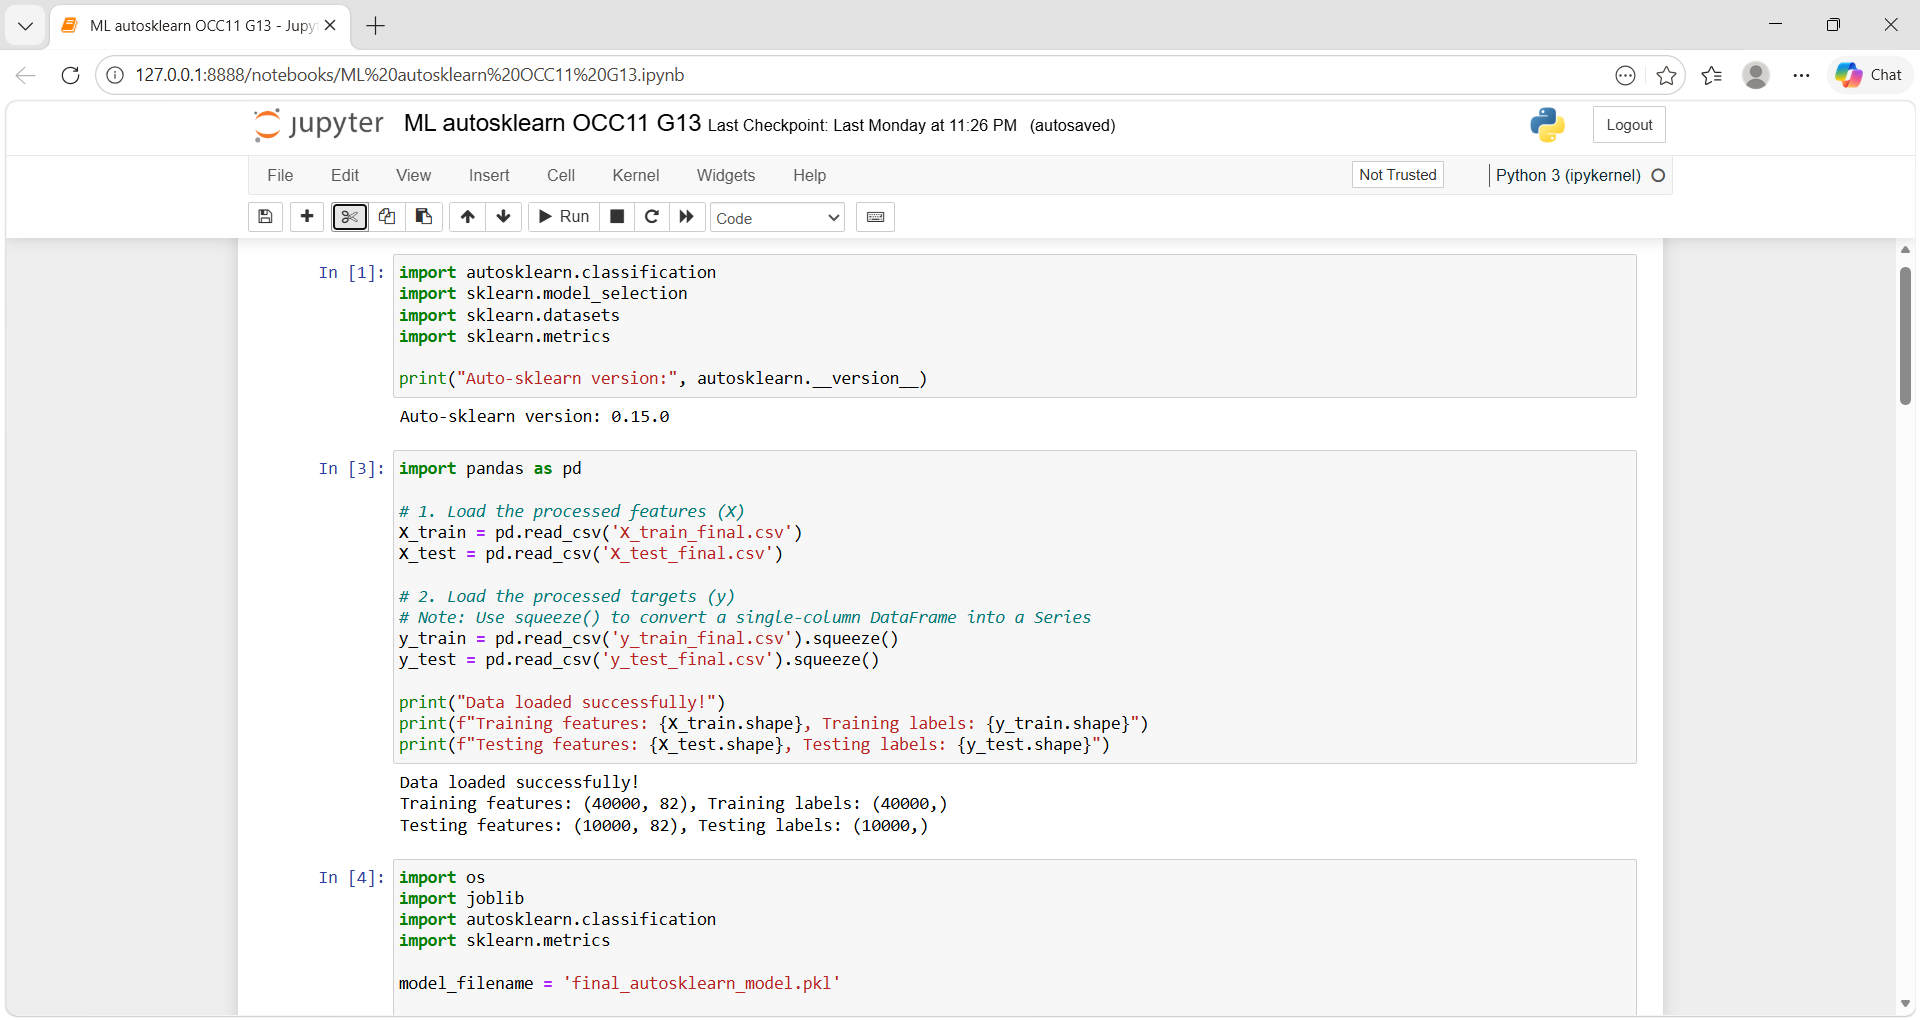

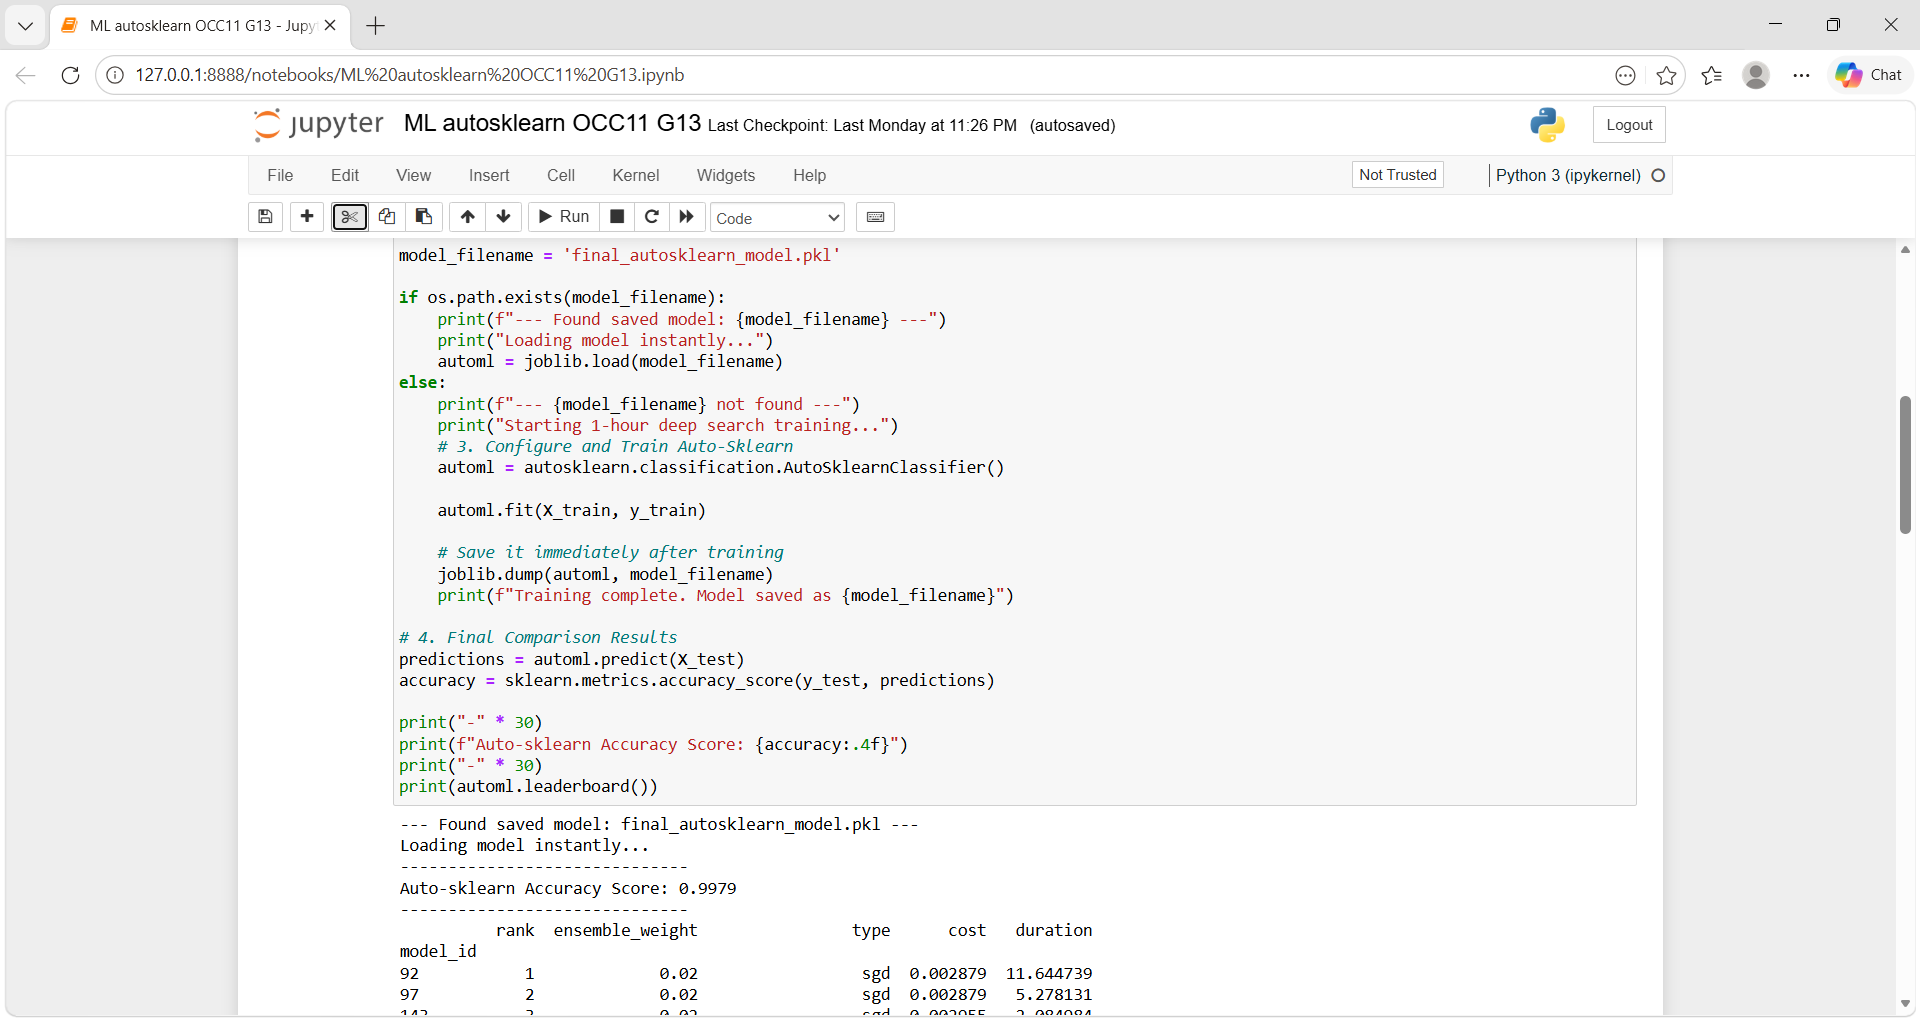

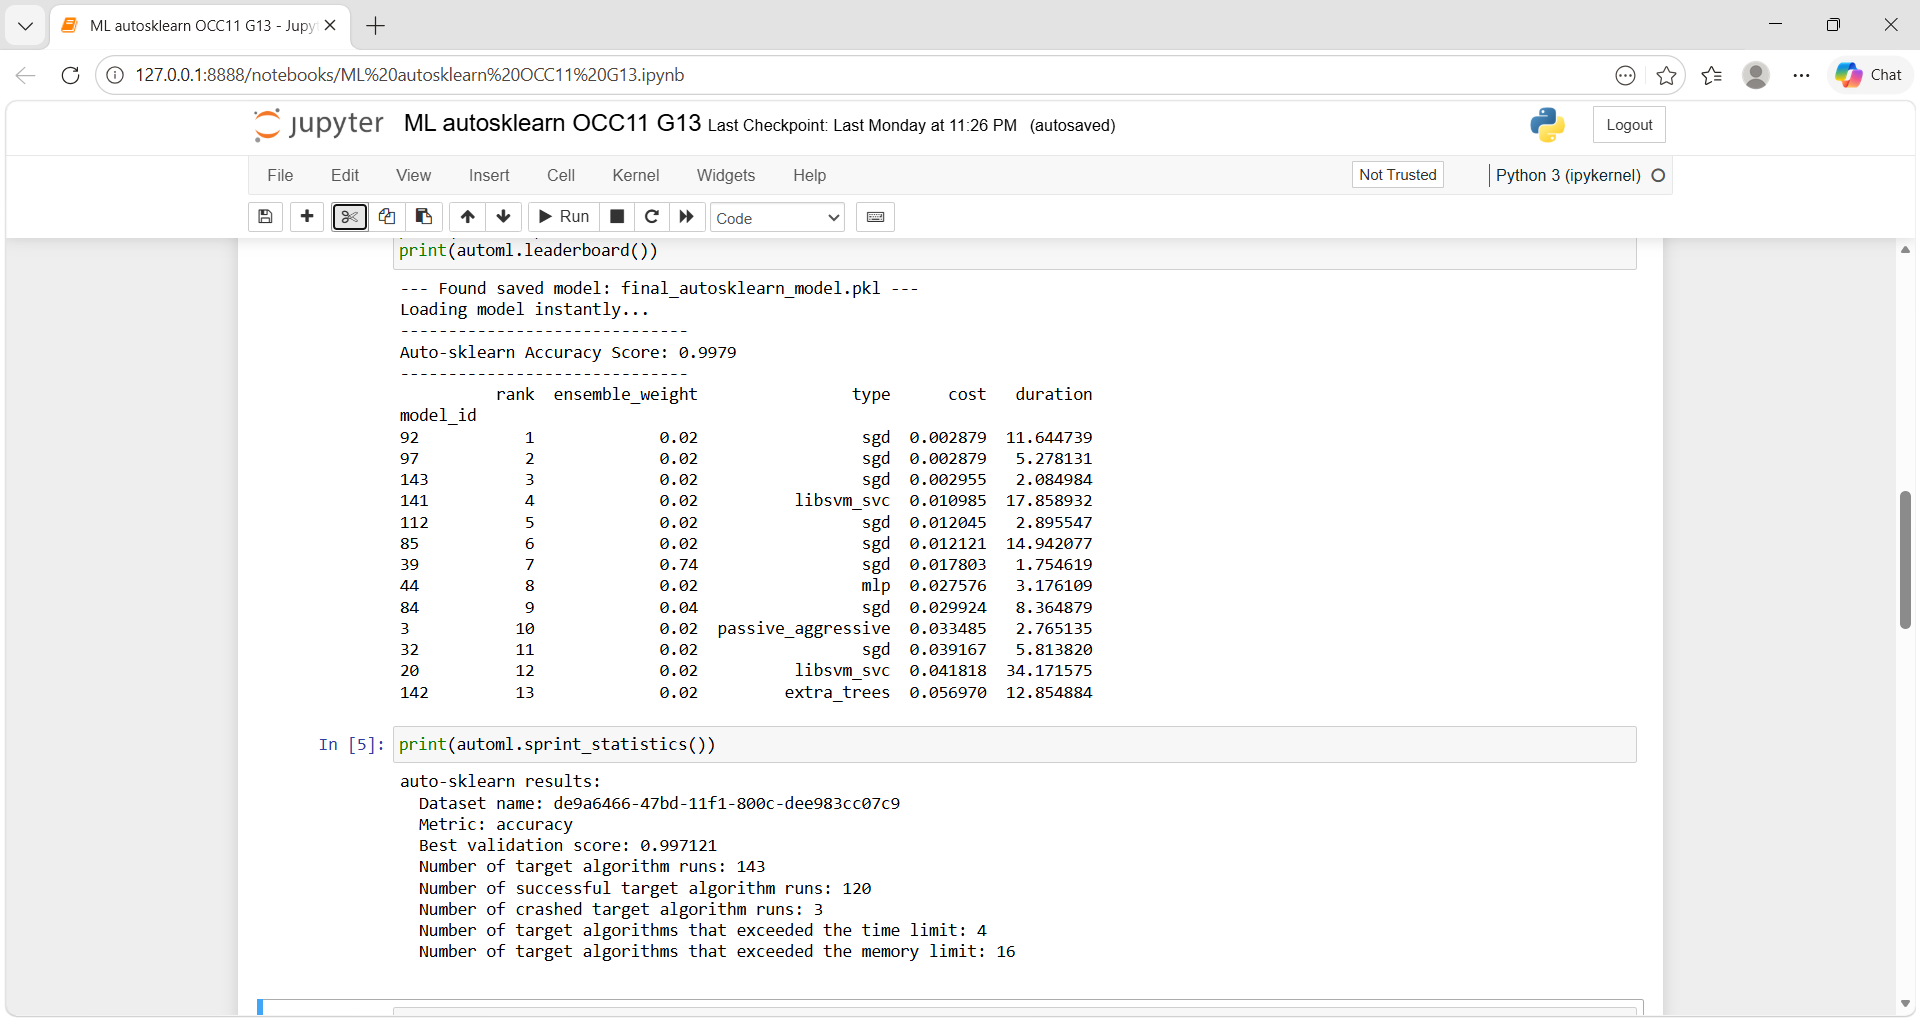

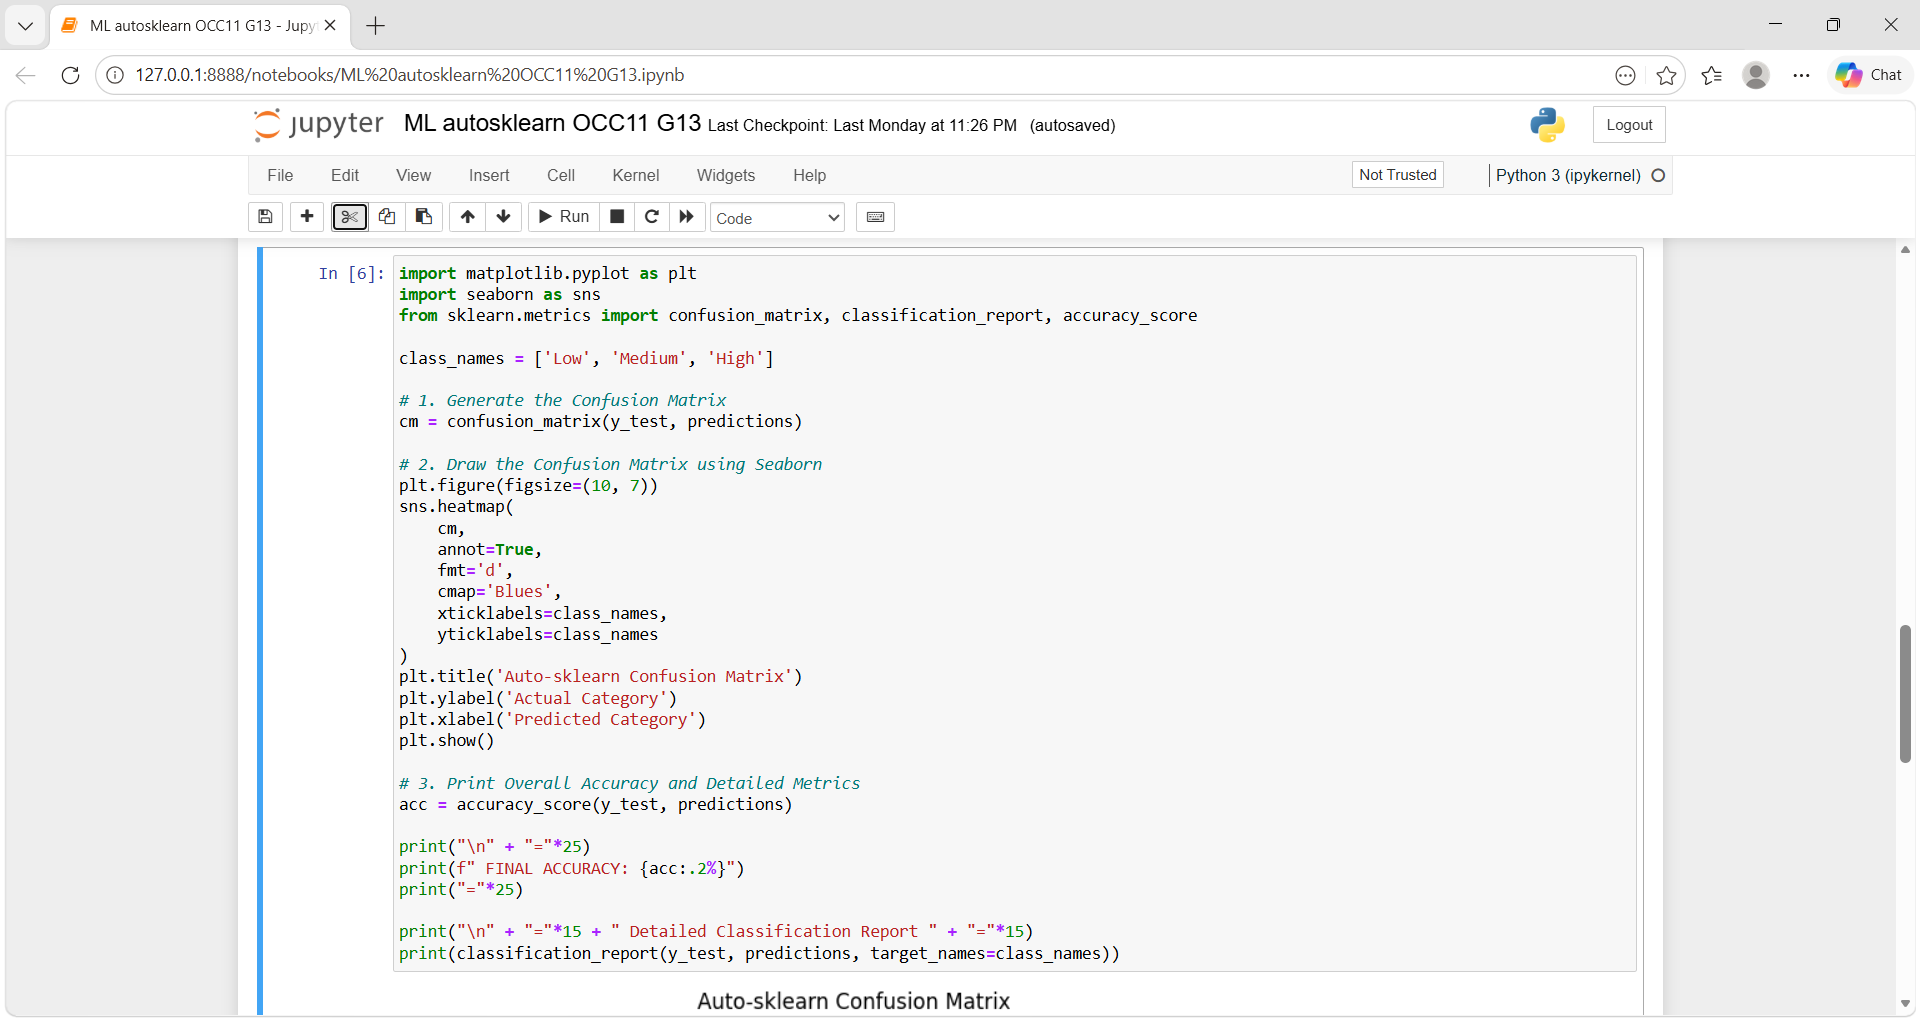

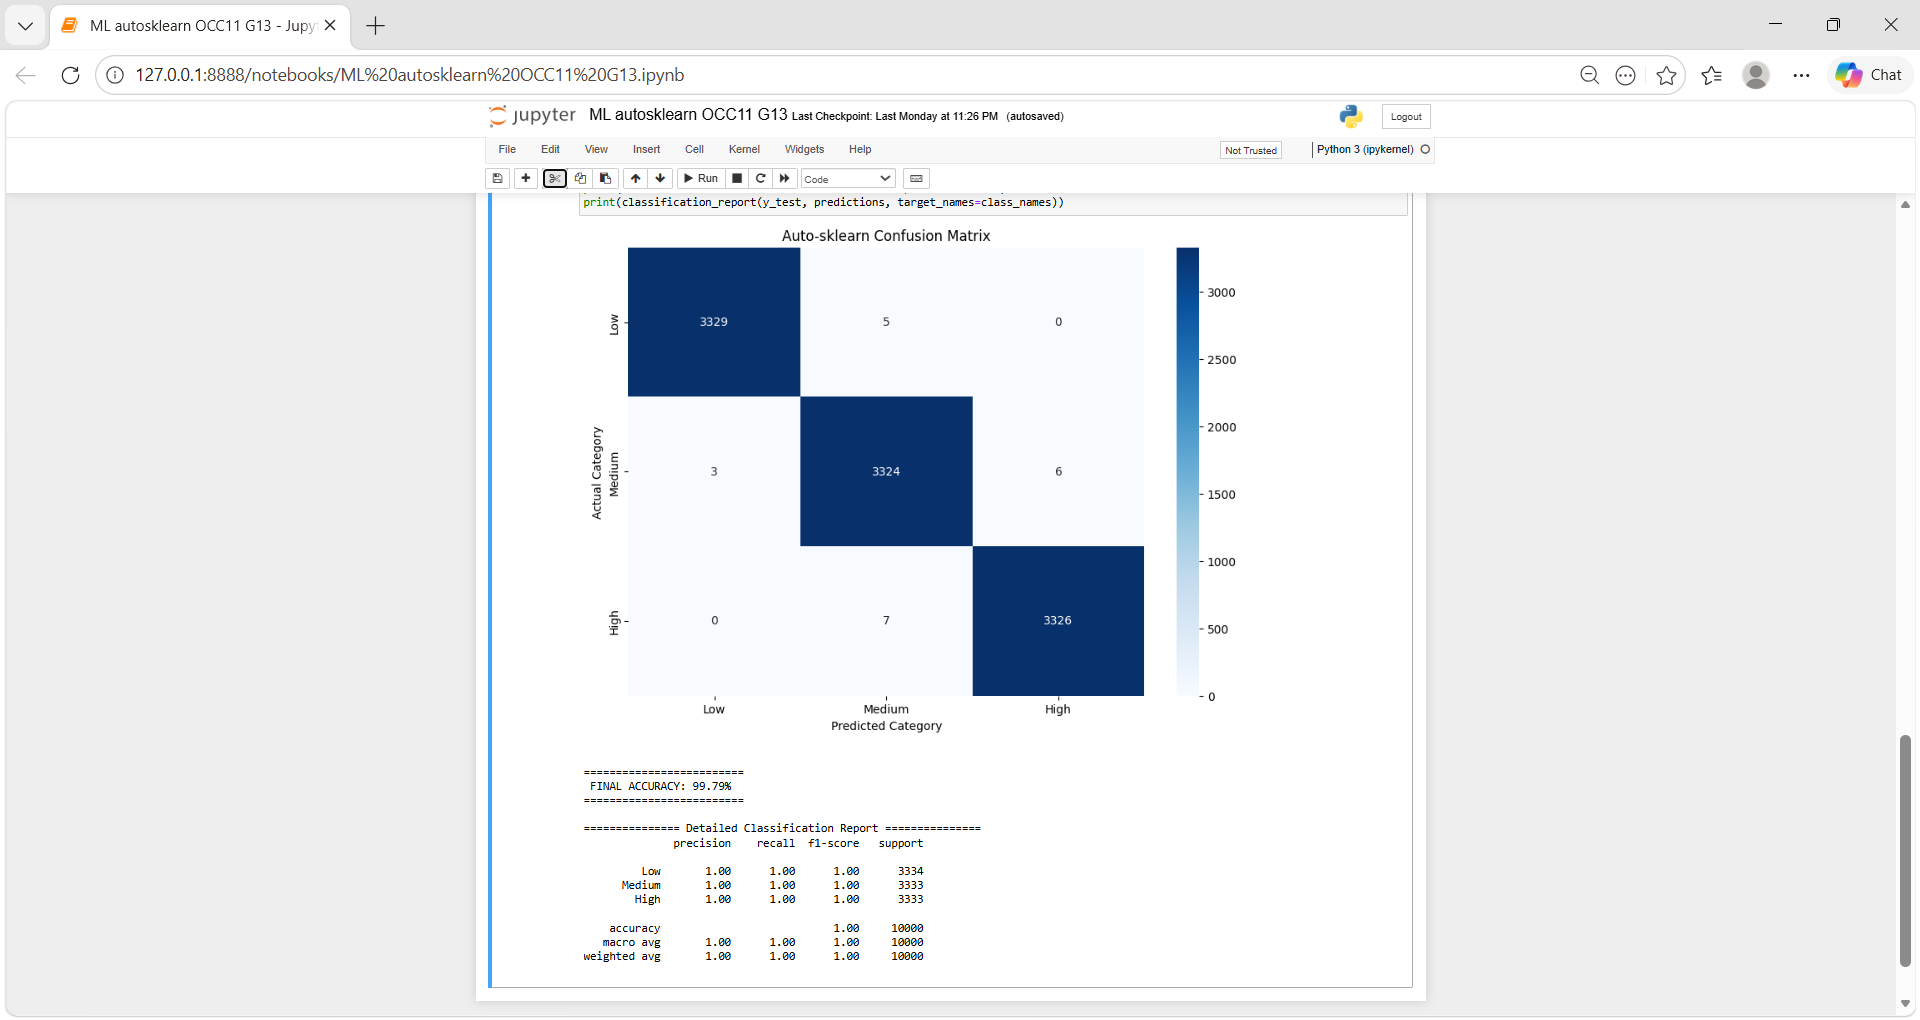

In [ ]:
# ------------------------------
# Auto-sklearn Accuracy Score: 0.9979
# ------------------------------
#           rank  ensemble_weight                type      cost   duration
# model_id
# 92           1             0.02                 sgd  0.002879  11.644739
# 97           2             0.02                 sgd  0.002879   5.278131
# 143          3             0.02                 sgd  0.002955   2.084984
# 141          4             0.02          libsvm_svc  0.010985  17.858932
# 112          5             0.02                 sgd  0.012045   2.895547
# 85           6             0.02                 sgd  0.012121  14.942077
# 39           7             0.74                 sgd  0.017803   1.754619
# 44           8             0.02                 mlp  0.027576   3.176109
# 84           9             0.04                 sgd  0.029924   8.364879
# 3           10             0.02  passive_aggressive  0.033485   2.765135
# 32          11             0.02                 sgd  0.039167   5.813820
# 20          12             0.02          libsvm_svc  0.041818  34.171575
# 142         13             0.02         extra_trees  0.056970  12.854884

In [ ]:
# =========================
#  FINAL ACCURACY: 99.79%
# =========================

# =============== Detailed Classification Report ===============
#               precision    recall  f1-score   support

#          Low       1.00      1.00      1.00      3334
#       Medium       1.00      1.00      1.00      3333
#         High       1.00      1.00      1.00      3333

#     accuracy                           1.00     10000
#    macro avg       1.00      1.00      1.00     10000
# weighted avg       1.00      1.00      1.00     10000

# 11.0 Model Evaluation

Comparing manual models (self-trained and self tuned model) with auto-sklearn

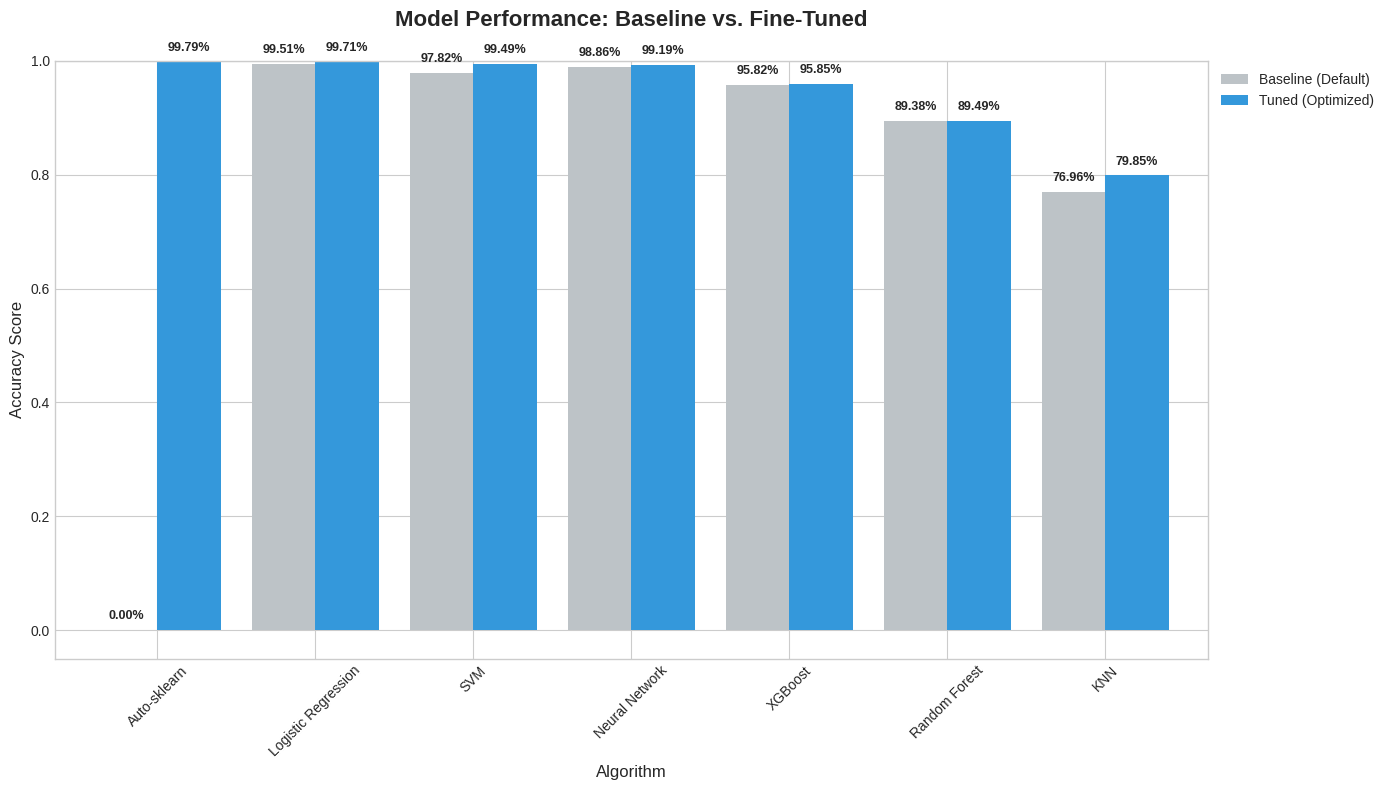

🏆 FINAL MODEL LEADERBOARD


,Model,Baseline Acc,Tuned Acc,Improvement
1,Auto-sklearn,0.0000,0.9979,0.9979
2,Logistic Regression,0.9951,0.9971,0.0020
3,SVM,0.9782,0.9949,0.0167
4,Neural Network,0.9886,0.9919,0.0033
5,XGBoost,0.9582,0.9585,0.0003
6,Random Forest,0.8938,0.8949,0.0011
7,KNN,0.7696,0.7985,0.0289


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Comparison DataFrame
comparison_data = []
for name in baseline_models.keys():
    b_acc = baseline_results.get(name, 0)
    t_acc = tuned_results.get(name, {}).get('accuracy', 0)

    comparison_data.append({
        'Model': name,
        'Baseline Acc': b_acc,
        'Tuned Acc': t_acc,
        'Improvement': t_acc - b_acc,
        'Best Params': str(tuned_results.get(name, {}).get('params', 'N/A'))
    })

# Auto-sklearn results
autosklearn_accuracy = 0.9979 # From what we trained in docker container
comparison_data.append({
    'Model': 'Auto-sklearn',
    'Baseline Acc': 0, # Auto-sklearn doesn't have a baseline
    'Tuned Acc': autosklearn_accuracy,
    'Improvement': autosklearn_accuracy,
    'Best Params': 'See detailed Auto-sklearn output'
})

leaderboard = pd.DataFrame(comparison_data).sort_values(by='Tuned Acc', ascending=False)
leaderboard = leaderboard.reset_index(drop=True)
leaderboard.index = leaderboard.index + 1

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

# Plotting
leaderboard.plot(x='Model', y=['Baseline Acc', 'Tuned Acc'], kind='bar',
                 ax=ax, color=['#bdc3c7', '#3498db'], width=0.8)

# Y-Axis Scaling
min_val = min(leaderboard['Baseline Acc'].min(), leaderboard['Tuned Acc'].min())
plt.ylim(min_val - 0.05, 1.0)

plt.title("Model Performance: Baseline vs. Fine-Tuned", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Algorithm", fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Baseline (Default)', 'Tuned (Optimized)'], loc='upper left', bbox_to_anchor=(1, 1))

# Data Labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Ranking Table
print("🏆 FINAL MODEL LEADERBOARD")
display(leaderboard[['Model', 'Baseline Acc', 'Tuned Acc', 'Improvement']])

# 12.0 Optional Task

A simple engagement class predictor app build with Stremlit, integrating models trained by auto-sklearn (our rank 1 model):

[Swipe Signals](https://swipe-signals-166746577811.asia-southeast1.run.app/)